# Progetto di Massive Data Mining: NLP con Disaster Tweets
**Studenti:** Giuseppe Rega, Felicita Giliberti


**Corso:** Massive Data Mining


**Obiettivo:** Sviluppare una pipeline *Data-Driven* completa per la classificazione di tweet ("Reali Disastri" vs "Fake/Metaforici").


## 1. Fase 1: Deep EDA & Pipeline di Preprocessing (Strategia A/B Testing)
Questa sezione iniziale è fondamentale per comprendere la struttura dei dati e prepararli per i modelli successivi. Viene eseguita una pipeline **parallela** per testare due diverse strategie di pulizia del testo.

**Attività Principali Svolte:**
* **Setup e Caricamento:** Importazione delle librerie (Pandas, Numpy, NLTK, Seaborn) e caricamento dei dataset `train.csv` e `test.csv`.
* **Analisi Esplorativa (EDA) Strutturale:**
    * Visualizzazione del bilanciamento delle classi (Disastri Reali vs Fake) tramite countplot.
    * Calcolo di meta-features come `char_length` (lunghezza caratteri) e `word_count` (conteggio parole).
    * Analisi statistica della tendenza centrale (Media, Mediana, Moda) per l'intero dataset e per classe.
* **Preprocessing Parallelo (A/B Testing):** Creazione di due versioni pulite del testo per confrontarne l'efficacia:
    * **Strategia A (Conservativa):** Rimozione URL/HTML, punteggiatura e numeri. Lemmatizzazione standard e rimozione stop words di base.
    * **Strategia B (Aggressiva):** Come la A, ma aggiunge la rimozione di stop words custom (`video`, `new`, ecc.) e parole troppo corte (< 2 caratteri).
* **Feature Engineering:** Creazione della colonna `final_text` (unione di `keyword` + testo pulito) per entrambe le strategie.
* **Analisi Semantica Avanzata:** Visualizzazione dei Top 15 Unigrammi e Bigrammi più frequenti per ciascuna classe (Disaster vs Fake) per identificare pattern linguistici.
* **Salvataggio Dati:** Export dei file `train_processed_dual.csv` e `test_processed_dual.csv` contenenti entrambe le versioni del preprocessing per le fasi successive.

Dataset Caricato: 7613 tweet di training, 3263 di test.


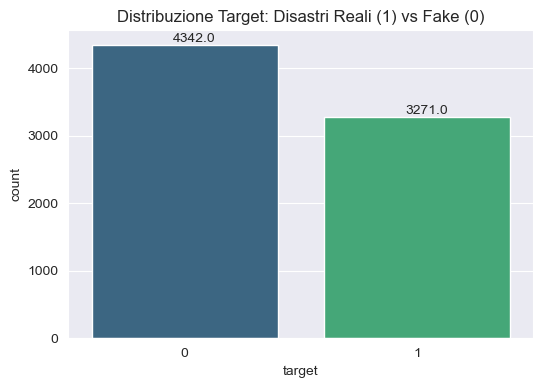

Media parole DISASTRI: 15.17
Media parole FAKE:     14.70

 2.1 ANALISI TENDENZA CENTRALE (Media, Mediana, Moda)
--- DATASET COMPLETO ---
         char_length  word_count
Media     101.037436   14.903586
Mediana   107.000000   15.000000
Moda      136.000000   11.000000

--- PER CLASSE (0=Fake vs 1=Disastro) ---
       char_length              word_count             
             Media Mediana Moda      Media Mediana Moda
target                                                 
0        95.706817   101.0  139  14.704744    15.0   11
1       108.113421   115.0  136  15.167533    15.0   18

 3. AVVIO PREPROCESSING PARALLELO (Strategia A vs B)
   -> Generazione colonne Strategia A...
   -> Generazione colonne Strategia B...

 4. CARATTERIZZAZIONE SEMANTICA (Basata su Strategia A)


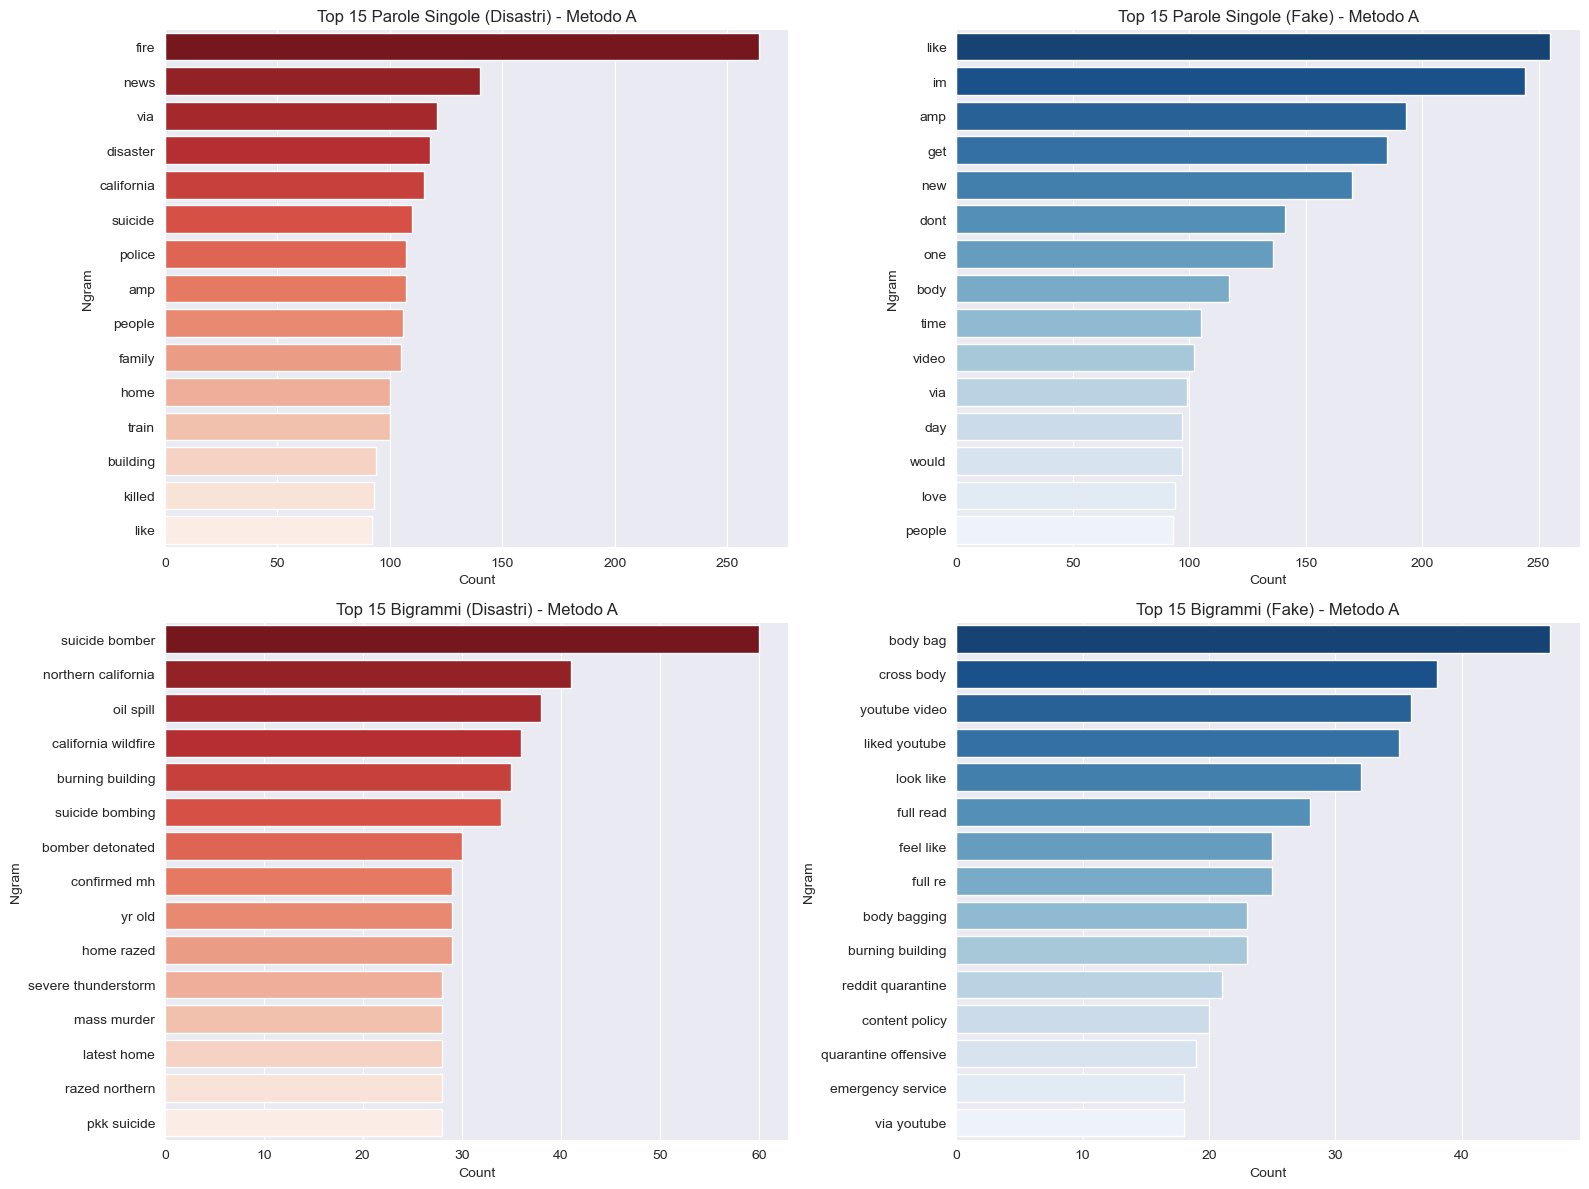


 File 'train_processed_dual.csv' salvato. Contiene sia pipeline A che B.


In [3]:
# Fase 1: Deep EDA & Preprocessing (PIPELINE PARALLELA A vs B)
import pandas as pd
import numpy as np
import re
import string
import nltk
import contextlib
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import warnings

# Ignora tutti i FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. SETUP E CARICAMENTO
with contextlib.redirect_stdout(None):
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    nltk.download('punkt_tab', quiet=True)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Dataset Caricato: {train.shape[0]} tweet di training, {test.shape[0]} di test.")

# 2. DEEP EDA: CARATTERIZZAZIONE STRUTTURALE

# A. Bilanciamento Target
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=train, palette='viridis')
plt.title('Distribuzione Target: Disastri Reali (1) vs Fake (0)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.35, p.get_height()+50))
plt.show()

# B. Creazione Meta-Features e Calcolo
train['char_length'] = train['text'].apply(len)
train['word_count'] = train['text'].apply(lambda x: len(str(x).split()))

print(f"Media parole DISASTRI: {train[train['target']==1]['word_count'].mean():.2f}")
print(f"Media parole FAKE:     {train[train['target']==0]['word_count'].mean():.2f}")

print("\n 2.1 ANALISI TENDENZA CENTRALE (Media, Mediana, Moda)")

# Funzione per calcolare la moda
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else np.nan

# 1. Statistiche dell'INTERO Dataset
print("--- DATASET COMPLETO ---")
global_stats = train[['char_length', 'word_count']].agg(['mean', 'median', get_mode])
global_stats = global_stats.rename(index={'mean': 'Media', 'median': 'Mediana', 'get_mode': 'Moda'})
print(global_stats)

# 2. Statistiche DIVISE per Target
print("\n--- PER CLASSE (0=Fake vs 1=Disastro) ---")
grouped_stats = train.groupby('target')[['char_length', 'word_count']].agg(['mean', 'median', get_mode])
grouped_stats = grouped_stats.rename(columns={'mean': 'Media', 'median': 'Mediana', 'get_mode': 'Moda'})
print(grouped_stats)


# --- 3. PIPELINE DI PULIZIA (MODIFICATA PER A/B TESTING) ---
print("\n 3. AVVIO PREPROCESSING PARALLELO (Strategia A vs B)")

lemmatizer = WordNetLemmatizer()
stop_words_std = set(stopwords.words('english'))

# --- STRATEGIA A: Conservativa (Simple) ---
# Mantiene stop words standard, NON filtra 'video', 'new', conserva parole brevi
def clean_text_A(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   #rimuove URL
    text = re.sub(r'<.*?>', '', text)                   #rimuove tag HTML
    text = text.translate(str.maketrans('', '', string.punctuation)) #rimuove caratteri speciali
    text = re.sub(r'\d+', '', text)     #rimuove numeri

    words = text.split()
    # Solo Lemmatizzazione e stop words standard
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words_std]
    return ' '.join(cleaned)

# --- STRATEGIA B: Aggressiva (Aggressive) ---
# Rimuove parole comuni custom e filtra parole corte (<2 char)
custom_stop_words = stop_words_std.union({'video', 'new', 'time', 'u', 'ur', 'im', 'cant', 'dont', 'go', 'get'})
def clean_text_B(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)

    words = text.split()
    # Filtri extra: custom stopwords e lunghezza > 1
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in custom_stop_words and len(w) > 1]
    return ' '.join(cleaned)

# --- APPLICAZIONE PARALLELA ---
print("   -> Generazione colonne Strategia A...")
train['clean_text_A'] = train['text'].apply(clean_text_A)
test['clean_text_A'] = test['text'].apply(clean_text_A)

print("   -> Generazione colonne Strategia B...")
train['clean_text_B'] = train['text'].apply(clean_text_B)
test['clean_text_B'] = test['text'].apply(clean_text_B)

# Gestione Keyword
train['keyword'] = train['keyword'].fillna('') #sostituisce Nan Con stringa vuota
test['keyword'] = test['keyword'].fillna('')

# Creazione Final Text per entrambe le strategie
train['final_text_A'] = (train['keyword'] + ' ' + train['clean_text_A']).str.strip()
test['final_text_A'] = (test['keyword'] + ' ' + test['clean_text_A']).str.strip()

train['final_text_B'] = (train['keyword'] + ' ' + train['clean_text_B']).str.strip()
test['final_text_B'] = (test['keyword'] + ' ' + test['clean_text_B']).str.strip()


# 4. ANALISI SEMANTICA AVANZATA
# (Nota: Usiamo la colonna 'clean_text_A' per i grafici, poiché è quella più leggibile)
print("\n 4. CARATTERIZZAZIONE SEMANTICA (Basata su Strategia A)")

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus) #crea vocabolario
    bag_of_words = vec.transform(corpus)                  #crea matrice che conta parole
    sum_words = bag_of_words.sum(axis=0)                  #somma tutte le colonne
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()] #crea lista di tuple (parola, punteggio totale)
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True) #ordina la lista
    return pd.DataFrame(words_freq[:top_k], columns=['Ngram', 'Count'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Usiamo clean_text_A per coerenza visiva
corpus_dis = train[train['target']==1]['clean_text_A']
corpus_fake = train[train['target']==0]['clean_text_A']

# A. Unigrammi
df_uni_dis = get_top_ngrams(corpus_dis, n=1)
df_uni_fake = get_top_ngrams(corpus_fake, n=1)

sns.barplot(x='Count', y='Ngram', data=df_uni_dis, palette='Reds_r', ax=axes[0,0])
axes[0,0].set_title('Top 15 Parole Singole (Disastri) - Metodo A')
sns.barplot(x='Count', y='Ngram', data=df_uni_fake, palette='Blues_r', ax=axes[0,1])
axes[0,1].set_title('Top 15 Parole Singole (Fake) - Metodo A')

# B. Bigrammi
df_bi_dis = get_top_ngrams(corpus_dis, n=2)
df_bi_fake = get_top_ngrams(corpus_fake, n=2)

sns.barplot(x='Count', y='Ngram', data=df_bi_dis, palette='Reds_r', ax=axes[1,0])
axes[1,0].set_title('Top 15 Bigrammi (Disastri) - Metodo A')
sns.barplot(x='Count', y='Ngram', data=df_bi_fake, palette='Blues_r', ax=axes[1,1])
axes[1,1].set_title('Top 15 Bigrammi (Fake) - Metodo A')

plt.tight_layout()
plt.show()



# --- 5. SALVATAGGIO ---
# Salviamo tutto. Nelle fasi successive sceglieremo se usare la colonna A o B.
train.to_csv('train_processed_dual.csv', index=False)
test.to_csv('test_processed_dual.csv', index=False)
print(f"\n File 'train_processed_dual.csv' salvato. Contiene sia pipeline A che B.")

## 1.b Espansione Preprocessing: Stemming
Dopo aver creato due pipeline di pulizia (A e B) basate sulla **Lemmatizzazione** (che riduce le parole alla loro forma base nel dizionario), in questa sotto-fase introduciamo un approccio più aggressivo: lo **Stemming**.

L'obiettivo è testare se una riduzione drastica del vocabolario (troncando le parole alla loro radice grezza) migliora le performance dei modelli classici come l'SVM, riducendo la sparsità della matrice TF-IDF.

**Attività Principali Svolte:**
* **Applicazione Porter Stemmer:** Utilizzo dell'algoritmo di Porter sulle colonne già pulite (`clean_text_A` e `clean_text_B`). Questo porta a una "doppia riduzione" (Lemma $\to$ Stem), massimizzando la compressione del vocabolario.
* **Analisi Statistica del Vocabolario:**
    * Calcolo e confronto delle dimensioni del vocabolario (numero di parole uniche) tra le versioni *Lemmatized* e *Stemmed*.
    * Visualizzazione grafica dell'impatto: ci aspettiamo una significativa riduzione dimensionale, utile per evitare l'overfitting su dataset piccoli.
* **Feature Engineering Finale (4 Varianti):**
    * Creazione delle colonne `final_text` anche per le versioni con stemming (concatenando sempre la `keyword`).
    * Generazione del dataset **`train_processed_4way.csv`**. Questo file è cruciale perché contiene ora **4 varianti di training** pronte per il benchmark:
        1.  **A_Lemma:** Conservativo + Dizionario (Alta precisione semantica).
        2.  **A_Stem:** Conservativo + Radice (Bassa dimensionalità).
        3.  **B_Lemma:** Aggressivo + Dizionario (Rumore ridotto).
        4.  **B_Stem:** Aggressivo + Radice (Massima sintesi).

In [1]:
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Serve sempre

# 1. Caricamento (se non è già in memoria)
try:
    # Cerchiamo train in memoria, altrimenti carichiamo il file duale della Fase 1
    if 'train' not in locals():
        train = pd.read_csv('train_processed_dual.csv')
        test = pd.read_csv('test_processed_dual.csv')
        print("Dataset caricati da file.")
    else:
        print("Dataset trovati in memoria.")
except FileNotFoundError:
    print("Errore: Esegui prima la Fase 1.")

print("\n--- 1.b GENERAZIONE VARIANTI STEMMING & ANALISI COMPARATIVA ---")

stemmer = PorterStemmer()

def apply_stemming(text):
    # Applica lo stemming a ogni parola del testo
    return ' '.join([stemmer.stem(word) for word in str(text).split()])

# --- 2. CREAZIONE COLONNE STEMMING (Fondamentale per le fasi successive) ---
print("Generazione colonne 'Stemmed' per Pipeline A e B...")

# Applichiamo lo stemming sulle colonne già pulite (che erano lemmatizzate)
# Nota: Tecnicamente stiamo facendo Lemma -> Stem, che è un approccio valido per ridurre al massimo.
train['clean_text_A_stem'] = train['clean_text_A'].apply(apply_stemming)
test['clean_text_A_stem'] = test['clean_text_A'].apply(apply_stemming)

train['clean_text_B_stem'] = train['clean_text_B'].apply(apply_stemming)
test['clean_text_B_stem'] = test['clean_text_B'].apply(apply_stemming)

# --- 3. ANALISI STATISTICA (Il tuo codice originale) ---

# Calcolo Statistiche per PIPELINE A
vocab_lemma_A = set()
train['clean_text_A'].str.split().apply(vocab_lemma_A.update)
len_lemma_A = len(vocab_lemma_A)

vocab_stem_A = set()
train['clean_text_A_stem'].str.split().apply(vocab_stem_A.update)
len_stem_A = len(vocab_stem_A)

# Calcolo Statistiche per PIPELINE B
vocab_lemma_B = set()
train['clean_text_B'].str.split().apply(vocab_lemma_B.update)
len_lemma_B = len(vocab_lemma_B)

vocab_stem_B = set()
train['clean_text_B_stem'].str.split().apply(vocab_stem_B.update)
len_stem_B = len(vocab_stem_B)

# Report Numerico
print(f"\n CONFRONTO DIMENSIONE VOCABOLARIO:")
print(f"{'Metodo':<25} | {'Lemma (Esistente)':<20} | {'Stem (Nuovo)':<15} | {'Riduzione':<10}")
print("-" * 80)
print(f"{'Pipeline A (Cons.)':<25} | {len_lemma_A:<20} | {len_stem_A:<15} | -{len_lemma_A - len_stem_A}")
print(f"{'Pipeline B (Aggr.)':<25} | {len_lemma_B:<20} | {len_stem_B:<15} | -{len_lemma_B - len_stem_B}")



# --- 4. PREPARAZIONE FINAL TEXT E SALVATAGGIO
print("\n--- PREPARAZIONE FILE FINALE (4 VARIANTI) ---")

# Gestione Keyword (fill NaN)
train['keyword'] = train['keyword'].fillna('')
test['keyword'] = test['keyword'].fillna('')

# Creiamo i 4 'final_text' che useremo nelle Fasi 2 e 3
# 1. A + Lemma (Già esisteva come final_text_A, ma lo rinominiamo per chiarezza)
# train['final_text_A_lemma'] = train['final_text_A'] # È ridondante ma chiaro

# 2. A + Stem
train['final_text_A_stem'] = (train['keyword'] + ' ' + train['clean_text_A_stem']).str.strip()
test['final_text_A_stem'] = (test['keyword'] + ' ' + test['clean_text_A_stem']).str.strip()

# 3. B + Lemma (Già esisteva come final_text_B)
# train['final_text_B_lemma'] = train['final_text_B']

# 4. B + Stem
train['final_text_B_stem'] = (train['keyword'] + ' ' + train['clean_text_B_stem']).str.strip()
test['final_text_B_stem'] = (test['keyword'] + ' ' + test['clean_text_B_stem']).str.strip()

# Salviamo tutto in un nuovo file "4way"
train.to_csv('train_processed_4way.csv', index=False)
test.to_csv('test_processed_4way.csv', index=False)

print(f" File 'train_processed_4way.csv' salvato correttamente.")
print("   Contiene le varianti: A_lemma (default), A_stem, B_lemma (default), B_stem.")

Dataset caricati da file.

--- 1.b GENERAZIONE VARIANTI STEMMING & ANALISI COMPARATIVA ---
Generazione colonne 'Stemmed' per Pipeline A e B...

 CONFRONTO DIMENSIONE VOCABOLARIO:
Metodo                    | Lemma (Esistente)    | Stem (Nuovo)    | Riduzione 
--------------------------------------------------------------------------------
Pipeline A (Cons.)        | 15815                | 14054           | -1761
Pipeline B (Aggr.)        | 15804                | 14044           | -1760

--- PREPARAZIONE FILE FINALE (4 VARIANTI) ---
 File 'train_processed_4way.csv' salvato correttamente.
   Contiene le varianti: A_lemma (default), A_stem, B_lemma (default), B_stem.


## 2. Fase 2: Deduplicazione Avanzata e Rimozione Conflitti (MinHash 4-Way)
Questa fase rappresenta il cuore del controllo qualità del dato. Non ci limitiamo a rimuovere i duplicati identici, ma utilizziamo l'algoritmo **MinHash (Locality Sensitive Hashing)** per identificare tweet "quasi identici" e, soprattutto, risolvere i **conflitti di etichettatura**.

**Il Problema dei "Dati Tossici":**
Nel dataset esistono tweet con testo identico (o con differenze minime come spazi/punteggiatura) che però hanno target opposti (uno è classificato come "Disastro", l'altro come "Fake"). Questi dati sono tossici perché confondono il modello durante il training, impedendo la convergenza.

**Metodologia (Pipeline MinHash):**
1.  **Shingling:** Il testo viene scomposto in set di coppie di parole contigue (*k-shingles*, con k=2).
2.  **MinHash Signature:** Viene calcolata una "firma digitale" probabilistica per ogni tweet. Tweet con alta somiglianza lessicale avranno la stessa firma.
3.  **Conflict Detection:**
    * Se due o più tweet hanno la stessa firma e lo **stesso target**, ne manteniamo uno solo (Deduplicazione standard).
    * Se due o più tweet hanno la stessa firma ma **target diversi**, li consideriamo **conflitti irrisolvibili** e rimuoviamo *tutti* gli esemplari coinvolti.

**Esecuzione Parallela (4-Way):**
Poiché lo *Stemming* (fatto nella Fase 1.b) rende le parole più simili tra loro (es. "running" diventa "run"), è probabile che la versione *Stemmed* riveli più duplicati rispetto alla versione *Lemmatized*.
Per questo motivo, eseguiamo la deduplicazione separatamente su tutte e 4 le varianti generate precedentemente:
* `A_Lemma` vs `A_Stem`
* `B_Lemma` vs `B_Stem`

**Output:**
Verranno generati **4 file distinti** (`train_dedup_A_lemma.csv`, ecc.). Questi dataset "puliti" saranno i concorrenti nel torneo di selezione del modello (Fase 3).

In [1]:
# Fase 2: Deduplicazione Avanzata (4-WAY PARALLEL)
import pandas as pd
import numpy as np
import hashlib

# 1. CARICAMENTO DATI
try:
    train = pd.read_csv('train_processed_4way.csv')
    print("File 'train_processed_4way.csv' caricato correttamente.")
except FileNotFoundError:
    print("ERRORE: Esegui prima la Fase 1.b modificata per generare il file 4way.")
    raise

# --- DEFINIZIONE FUNZIONI MINHASH ---
def get_shingles(text, k=2):
    if pd.isna(text): return set()
    words = str(text).split()
    if len(words) < k: return {str(text)}
    return set(' '.join(words[i:i+k]) for i in range(len(words) - k + 1))

def compute_minhash_signature(shingles, num_hashes=100):
    if not shingles: return [0] * num_hashes
    shingle_hashes = [int(hashlib.md5(s.encode('utf-8')).hexdigest(), 16) % (2**32) for s in shingles]
    np.random.seed(42)
    random_seeds = np.random.randint(0, 2**32, num_hashes)
    signature = []
    for seed in random_seeds:
        min_val = min([h ^ seed for h in shingle_hashes])
        signature.append(min_val)
    return tuple(signature)

# --- FUNZIONE CORE CHE RESTITUISCE STATISTICHE ---
def run_deduplication_pipeline(df, text_column, strategy_name):
    """
    Esegue la pipeline MinHash e restituisce:
    1. Il dataframe pulito
    2. Un dizionario con le statistiche
    """
    # Lavoriamo su una copia
    df_work = df.copy()
    initial_len = len(df_work)

    # 1. Shingles e MinHash
    df_work['shingles'] = df_work[text_column].apply(get_shingles)
    df_work['minhash_sig'] = df_work['shingles'].apply(compute_minhash_signature)

    # 2. Ricerca Conflitti
    seen_signatures = {}
    duplicates_count = 0
    conflicting_indices = []

    for idx, row in df_work.iterrows():
        sig = row['minhash_sig']
        target = row['target']

        if sig in seen_signatures:
            duplicates_count += 1
            original_idx = seen_signatures[sig]['idx']
            original_target = seen_signatures[sig]['target']

            # Conflitto di etichetta?
            if target != original_target:
                conflicting_indices.append(idx)
                conflicting_indices.append(original_idx)
        else:
            seen_signatures[sig] = {'idx': idx, 'target': target}

    # Rimuoviamo duplicati dalla lista conflitti per contarli una sola volta
    conflicting_indices = list(set(conflicting_indices))
    conflicts_count = len(conflicting_indices)

    # 3. Rimozione
    if conflicts_count > 0:
        df_clean = df_work.drop(conflicting_indices)
    else:
        df_clean = df_work

    final_len = len(df_clean)

    # Pulizia colonne temporanee
    df_clean = df_clean.drop(columns=['shingles', 'minhash_sig'])

    # Creazione Dizionario Statistiche
    stats = {
        "Strategy": strategy_name,
        "Original Rows": initial_len,
        "Duplicates Found": duplicates_count,
        "Conflicting IDs (Removed)": conflicts_count,
        "Final Rows": final_len,
        "Output File": f"train_dedup_{strategy_name}.csv" # Nome generico, verrà sovrascritto nel loop
    }

    return df_clean, stats

# --- ESECUZIONE PARALLELA E GENERAZIONE TABELLA ---

variants = [
    ("A_Lemma", "clean_text_A",      "final_text_A",      "train_dedup_A_lemma.csv"),
    ("A_Stem",  "clean_text_A_stem", "final_text_A_stem", "train_dedup_A_stem.csv"),
    ("B_Lemma", "clean_text_B",      "final_text_B",      "train_dedup_B_lemma.csv"),
    ("B_Stem",  "clean_text_B_stem", "final_text_B_stem", "train_dedup_B_stem.csv")
]

print("\n AVVIO DEDUPLICAZIONE QUADRUPLA...")

all_stats = [] # Lista per raccogliere i dati della tabella

for name, clean_col, final_col, filename in variants:
    # Eseguiamo pipeline e otteniamo dati + statistiche
    df_result, stat_dict = run_deduplication_pipeline(train, clean_col, name)

    # Aggiorniamo il nome file corretto nelle statistiche
    stat_dict["Output File"] = filename
    all_stats.append(stat_dict)

    # Standardizziamo e salviamo
    df_result['final_text'] = df_result[final_col]
    df_result.to_csv(filename, index=False)

# --- VISUALIZZAZIONE TABELLA FINALE ---
print("\n" + "="*80)
print(" RISULTATI DEDUPLICAZIONE (COMPARATIVA)")
print("="*80)

# Creiamo il DataFrame di riepilogo
df_summary = pd.DataFrame(all_stats)

# Visualizzazione pulita
# Se sei su Colab/Jupyter, questo stamperà una tabella formattata
try:
    from IPython.display import display
    display(df_summary)
except ImportError:
    print(df_summary.to_string(index=False))

print("="*80)

File 'train_processed_4way.csv' caricato correttamente.

 AVVIO DEDUPLICAZIONE QUADRUPLA...

 RISULTATI DEDUPLICAZIONE (COMPARATIVA)


,Strategy,Original Rows,Duplicates Found,Conflicting IDs (Removed),Final Rows,Output File
0,A_Lemma,7613,748,204,7409,train_dedup_A_lemma.csv
1,A_Stem,7613,752,206,7407,train_dedup_A_stem.csv
2,B_Lemma,7613,756,207,7406,train_dedup_B_lemma.csv
3,B_Stem,7613,760,209,7404,train_dedup_B_stem.csv


## 3. Model Selection Tournament: Data-Centric Benchmarking
In questa fase, adottiamo un approccio **Data-Centric AI**. Invece di limitarci a ottimizzare gli iperparametri di un singolo modello, mettiamo in competizione le **4 varianti di dataset** generate nella Fase 2 per scoprire empiricamente quale strategia di preprocessing massimizzi la capacità predittiva dell'SVM.

**La Strategia: Full-Feature Space**
: passiamo all'SVM l'intera matrice **TF-IDF sparsa**. Questo permette al modello di accedere a tutto il vocabolario (fino a 14.000 feature) per intercettare anche i segnali più deboli.

**Il Torneo (4-Way Comparison):**
Il codice esegue un loop automatico su:
1.  **A_Lemma:** Pulizia standard + Lemmatizzazione.
2.  **A_Stem:** Pulizia standard + Stemming (Radice).
3.  **B_Lemma:** Pulizia aggressiva (Stopwords custom) + Lemmatizzazione.
4.  **B_Stem:** Pulizia aggressiva + Stemming.

**Analisi Avanzata degli Errori:**
Oltre all'**F1-Score**, il codice genera **le Matrici di Confusione**.
Al termine, una tabella riassuntiva decreterà il **Vincitore Assoluto**, che verrà utilizzato per generare il file di sottomissione finale.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import warnings

# Ignoriamo warning minori
warnings.filterwarnings("ignore")

# --- DEFINIZIONE DEI 4 DATASET DA TESTARE ---
datasets_config = [
    {'name': 'A_Lemma', 'train_file': 'train_dedup_A_lemma.csv', 'test_col': 'final_text_A'},
    {'name': 'A_Stem',  'train_file': 'train_dedup_A_stem.csv',  'test_col': 'final_text_A_stem'},
    {'name': 'B_Lemma', 'train_file': 'train_dedup_B_lemma.csv', 'test_col': 'final_text_B'},
    {'name': 'B_Stem',  'train_file': 'train_dedup_B_stem.csv',  'test_col': 'final_text_B_stem'}
]

# 1. CONFIGURAZIONE GRIGLIA
params_grid = {
    'tfidf': [
        {'min_df': 2, 'ngram_range': (1, 1)},
        {'min_df': 3, 'ngram_range': (1, 2)},
        {'min_df': 3, 'ngram_range': (1, 3)}
    ]
}

# Strutture per salvare i risultati
results_list = []
global_best_score = -1
global_best_pipeline_name = ""
global_best_models = {}

print(" AVVIO TORNEO AUTOML: ANALISI APPROFONDITA (4 MATRICI)")
print("="*60)


# --- CARICAMENTO TEST SET UNICO ---
try:
    test_full = pd.read_csv('test_processed_4way.csv')
    print(" Test Set caricato.")
except FileNotFoundError:
    print("ERRORE CRITICO: Manca 'test_processed_4way.csv'.")
    raise

# --- LOOP SUI 4 DATASET ---
for idx, ds_conf in enumerate(datasets_config):
    pipe_name = ds_conf['name']
    filename = ds_conf['train_file']

    print(f"\n ANALISI PIPELINE: {pipe_name}")

    try:
        train = pd.read_csv(filename).dropna(subset=['final_text'])
        train_text = train['final_text'].astype(str)
        y = train['target']
    except FileNotFoundError:
        print(f"   ️ File {filename} non trovato. Saltato.")
        continue

    # Setup Cross Validation
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Variabili per il miglior locale
    local_best_f1 = -1
    local_best_params = {}
    local_best_clf = None
    local_best_X = None

    # AUTOML (Trova la migliore config TF-IDF per QUESTO dataset)
    for tfidf_params in params_grid['tfidf']:
        tfidf = TfidfVectorizer(min_df=tfidf_params['min_df'], ngram_range=tfidf_params['ngram_range'], sublinear_tf=True)
        X_tfidf = tfidf.fit_transform(train_text)
        clf = SVC(C=1.0, kernel='rbf', random_state=42)

        scores = cross_val_score(clf, X_tfidf, y, cv=cv_strategy, scoring='f1')
        mean_f1 = np.mean(scores)


        if mean_f1 > local_best_f1:
            local_best_f1 = mean_f1
            local_best_params = tfidf_params
            local_best_clf = clf
            local_best_X = X_tfidf
            local_best_vectorizer = tfidf

    print(f"    Best Locale: F1 {local_best_f1:.5f} (Params: {local_best_params['ngram_range']})")

    # --- CALCOLO MATRICE DI CONFUSIONE PER IL MIGLIORE LOCALE ---
    y_pred_cv = cross_val_predict(local_best_clf, local_best_X, y, cv=cv_strategy)
    cm = confusion_matrix(y, y_pred_cv)
    tn, fp, fn, tp = cm.ravel()

    # Salviamo i dati per la tabella finale
    results_list.append({
        'Dataset': pipe_name,
        'Best Params': str(local_best_params['ngram_range']),
        'F1 Score': local_best_f1,
        'Falsi Negativi (FN)': fn,
        'Falsi Positivi (FP)': fp
    })

    # Check Global Winner
    if local_best_f1 > global_best_score:
        global_best_score = local_best_f1
        global_best_pipeline_name = pipe_name
        global_best_models = {'tfidf': local_best_vectorizer, 'clf': local_best_clf}
        global_train_data = (local_best_X, y)


# --- TABELLA RIASSUNTIVA FINALE ---
print("\n" + "="*60)
print(" CONFRONTO FINALE 4 CATEGORIE")
print("="*60)
df_results = pd.DataFrame(results_list).sort_values(by='F1 Score', ascending=False)
display(df_results)

print("\n" + "="*60)
print(f"  VINCITORE ASSOLUTO: {global_best_pipeline_name}")
print(f"    F1 Score: {global_best_score:.5f}")
print("="*60)

# --- 4. CREAZIONE SUBMISSION VINCENTE ---
print(f"\n Generazione Submission con il vincitore {global_best_pipeline_name}...")
if global_best_models:
    test_col_name = next(item['test_col'] for item in datasets_config if item['name'] == global_best_pipeline_name)
    test_text = test_full[test_col_name].astype(str)

    # Retraining finale su tutto il dataset
    X_best, y_best = global_train_data
    clf_final = global_best_models['clf']
    tfidf_final = global_best_models['tfidf']

    clf_final.fit(X_best, y_best)

    X_test_final = tfidf_final.transform(test_text)
    predictions = clf_final.predict(X_test_final)

    filename = f'submission_winner_{global_best_pipeline_name}_optimized.csv'
    pd.DataFrame({'id': test_full['id'], 'target': predictions}).to_csv(filename, index=False)
    print(f" File '{filename}' creato con successo!")

 AVVIO TORNEO AUTOML: ANALISI APPROFONDITA (4 MATRICI)
 Test Set caricato.

 ANALISI PIPELINE: A_Lemma
    Best Locale: F1 0.76554 (Params: (1, 1))

 ANALISI PIPELINE: A_Stem
    Best Locale: F1 0.77293 (Params: (1, 2))

 ANALISI PIPELINE: B_Lemma
    Best Locale: F1 0.76627 (Params: (1, 3))

 ANALISI PIPELINE: B_Stem
    Best Locale: F1 0.76459 (Params: (1, 2))

 CONFRONTO FINALE 4 CATEGORIE


,Dataset,Best Params,F1 Score,Falsi Negativi (FN),Falsi Positivi (FP)
1,A_Stem,"(1, 2)",0.772930,956,349
2,B_Lemma,"(1, 3)",0.766266,966,383
0,A_Lemma,"(1, 1)",0.765544,970,382
3,B_Stem,"(1, 2)",0.764592,983,367



  VINCITORE ASSOLUTO: A_Stem
    F1 Score: 0.77293

 Generazione Submission con il vincitore A_Stem...
 File 'submission_winner_A_Stem_optimized.csv' creato con successo!


## 4. Fase 4: Surgical Tuning (Ottimizzazione Iperparametri)
Identificata la pipeline vincente (**Dataset A_Stem** + **TF-IDF Bigrammi**) nella fase precedente, ora procediamo con un'ottimizzazione "chirurgica" (Surgical Tuning) del modello SVM. Non cerchiamo più quale modello usare, ma cerchiamo la **configurazione matematica perfetta** per quel modello specifico.

**Obiettivi e Metodologia:**
* **Focus Esclusivo sul Vincitore:** Carichiamo solo il dataset `train_dedup_A_stem.csv`, ignorando le altre varianti ormai scartate.
* **Vettorizzazione Consolidata:** Applichiamo la trasformazione TF-IDF a Bigrammi `(1, 2)` che si è rivelata la migliore nel torneo precedente.
* **Grid Search Mirata:** Eseguiamo una ricerca esaustiva su due iperparametri critici dell'SVM:
    * **Parametro `C` (Regolarizzazione):** Controlla quanto il modello deve adattarsi ai dati di training. Un C basso generalizza meglio (evita overfitting), un C alto cerca di classificare correttamente ogni singolo punto (rischio overfitting). Testiamo un range fine (0.5 - 2.0).
    * **Parametro `class_weight`:** Testiamo l'opzione `'balanced'`. Dato che i disastri sono la classe minoritaria, questa opzione aumenta la penalità per i **Falsi Negativi**, costringendo il modello a essere meno "pigro" e a recuperare più disastri reali.
* **Verifica Differenziale:** Calcoliamo la matrice di confusione finale e confrontiamo esplicitamente il numero di Falsi Negativi con la Fase 3. L'obiettivo è vedere se il tuning ha recuperato disastri che prima venivano ignorati.

1. Caricamento Dataset Vincitore (A_Stem)...
   Dati pronti: 7407 righe di training.

2. Applicazione TF-IDF (Configurazione Vincente: Bigrammi)...
   Matrice Feature: (7407, 11047) (Sparse)

3. Avvio Tuning Finale (Surgical Tuning)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

 RISULTATI TUNING FINALE:
 Migliori parametri: {'C': 1.2, 'class_weight': 'balanced'}
 Miglior F1 Score (CV): 0.77508

 Verifica Impatto Tuning (Matrice di Confusione)...


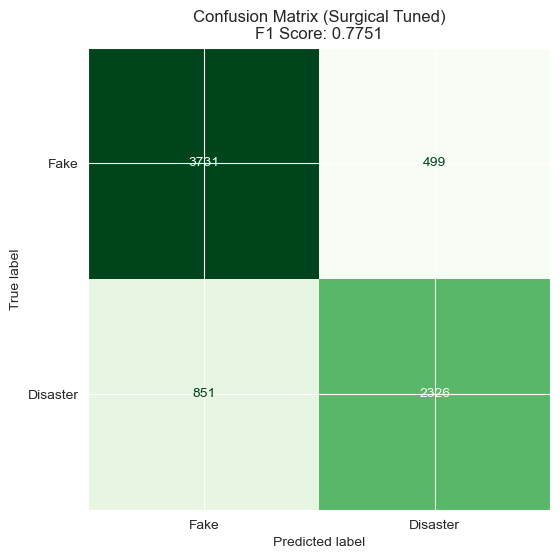


 REPORT MIGLIORAMENTO:
- Falsi Negativi (Fase 3): 956
- Falsi Negativi (Fase 4): 851
 RISULTATO: Abbiamo recuperato 105 disastri veri!

4. Generazione 'submission_ultimate_tuned.csv'...
 File creato con successo!


In [21]:
# --- FASE 4: SURGICAL TUNING (SUL VINCITORE A_STEM) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. CARICAMENTO DATI DEL VINCITORE (A_Stem)
print("1. Caricamento Dataset Vincitore (A_Stem)...")
try:
    # Usiamo il file specifico che ha vinto la Fase 3
    train = pd.read_csv('train_dedup_A_stem.csv').dropna(subset=['final_text_A_stem'])
    test = pd.read_csv('test_processed_4way.csv') # Il test set completo

    # Prepariamo le colonne corrette
    # Nota: Assicurati che i nomi coincidano con quelli usati in Fase 3
    X_raw = train['final_text_A_stem'].astype(str)
    y = train['target']

    X_test_raw = test['final_text_A_stem'].astype(str) # Usiamo la colonna A_stem anche per il test
    ids_test = test['id']

    print(f"   Dati pronti: {len(X_raw)} righe di training.")

except FileNotFoundError:
    print("ERRORE: File mancanti. Assicurati di aver eseguito Fase 1.b e Fase 2.")
    raise

# 2. VETTORIZZAZIONE (Configurazione Vincente Fase 3)
print("\n2. Applicazione TF-IDF (Configurazione Vincente: Bigrammi)...")
# Abbiamo visto che (1, 2) dava 0.773, usiamo quella.
tfidf = TfidfVectorizer(
    min_df=2,
    ngram_range=(1, 2), # Bigrammi
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(X_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"   Matrice Feature: {X_tfidf.shape} (Sparse)")

# 3. TUNING GRID SEARCH (Ottimizzazione C e Bilanciamento)
print("\n3. Avvio Tuning Finale (Surgical Tuning)...")

# SVM Puro (Senza Pipeline complessa perché i dati sono già trasformati)
svm = SVC(kernel='rbf', probability=True, random_state=42)

# Griglia di precisione
# Testiamo C (regolarizzazione) e class_weight (bilanciamento errori)
param_grid = {
    'C': [0.5, 0.8, 1.0, 1.1, 1.2, 1.3, 1.5, 2.0],
    'class_weight': [None, 'balanced'] # 'balanced' penalizza di più i Falsi Negativi
}

grid = GridSearchCV(
    svm,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_tfidf, y)

print("\n" + "="*50)
print(f" RISULTATI TUNING FINALE:")
print(f" Migliori parametri: {grid.best_params_}")
print(f" Miglior F1 Score (CV): {grid.best_score_:.5f}")
print("="*50)

# --- ANALISI IMPATTO ---
print("\n Verifica Impatto Tuning (Matrice di Confusione)...")

best_model = grid.best_estimator_
y_pred_tuned = cross_val_predict(best_model, X_tfidf, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

cm = confusion_matrix(y, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Disaster'])
disp.plot(cmap='Greens', values_format='d', ax=plt.gca(), colorbar=False)
plt.title(f'Confusion Matrix (Surgical Tuned)\nF1 Score: {grid.best_score_:.4f}')
plt.show()

# Report Confronto
print("\n REPORT MIGLIORAMENTO:")
# Usiamo i dati della Fase 3 come riferimento (FN erano 956)
fn_ref = 956
print(f"- Falsi Negativi (Fase 3): {fn_ref}")
print(f"- Falsi Negativi (Fase 4): {fn}")
diff = fn_ref - fn

if diff > 0:
    print(f" RISULTATO: Abbiamo recuperato {diff} disastri veri!")
else:
    print(f" RISULTATO: Nessun miglioramento sui FN.")

# --- SALVATAGGIO ---
filename = 'submission_ultimate_tuned.csv'
print(f"\n4. Generazione '{filename}'...")
predictions = best_model.predict(X_test_tfidf)
pd.DataFrame({'id': ids_test, 'target': predictions}).to_csv(filename, index=False)
print(" File creato con successo!")

## 5. Fase 5: Benchmark Comparativo & Analisi di Correlazione (Dataset A_Stem)

Dopo aver stabilito nella **Fase 4** che la combinazione `Dataset A_Stem + TF-IDF Bigrammi + SVM Tuned` è la nostra configurazione **"Campione"**, in questa fase cerchiamo i partner ideali per l'Ensemble.

Manteniamo rigorosamente congelati il dataset (`train_dedup_A_stem.csv`) e la pipeline di vettorizzazione. L'unica variabile che cambia è l'**algoritmo di classificazione**.

**Confrontiamo:**
*   **SVM Tuned:** Il nostro riferimento (*Baseline*).
*   **SGD Classifier:** Ottimizzato per il recupero (spesso presenta meno Falsi Negativi).
*   **Multinomial Naive Bayes (MNB):** Probabilistico e strutturalmente diverso dai modelli lineari (candidato ideale per la diversità).
*   **Logistic Regression & Ridge:** Benchmark lineari classici.

###  Obiettivo dell'Analisi
Oltre al punteggio **F1**, generiamo una **Matrice di Correlazione** tra le predizioni.

> Per costruire un **Ensemble** vincente nella Fase 6, non cerchiamo solo modelli precisi, ma modelli **"Ortogonali"** (bassa correlazione) che correggano gli errori dell'SVM invece di replicarli.


 AVVIO FASE 5: CREAZIONE ENSEMBLE SU DATI VINCITORI (A_STEM)
1. Caricamento 'train_dedup_A_stem.csv'...
   -> Dati pronti: 7407 righe.
   -> Target: {0: 4230, 1: 3177}

2. Vettorizzazione TF-IDF (Bigrammi)...
   -> Features: (7407, 11047)

3. Benchmark Modelli (CV)...
   -> 1. SVM Tuned (RBF, C=1.2, Balanced)...
   -> 2. SGD Classifier (Log Loss)...
   -> 3. Logistic Regression...
   -> 4. Ridge Classifier...
   -> 5. Multinomial NB...

MODELLO         | F1 SCORE   | FALSE NEG  | FALSE POS  | ACCURACY  
-------------------------------------------------------------------------------------
SVM_Tuned       | 0.77507     | 851        | 499        | 0.81774
SGD_Opt         | 0.77419     | 741        | 680        | 0.80815
LogReg          | 0.77588     | 745        | 660        | 0.81031
Ridge           | 0.77120     | 762        | 671        | 0.80653
MNB             | 0.76768     | 973        | 361        | 0.81990

 Generazione Matrice di Correlazione...


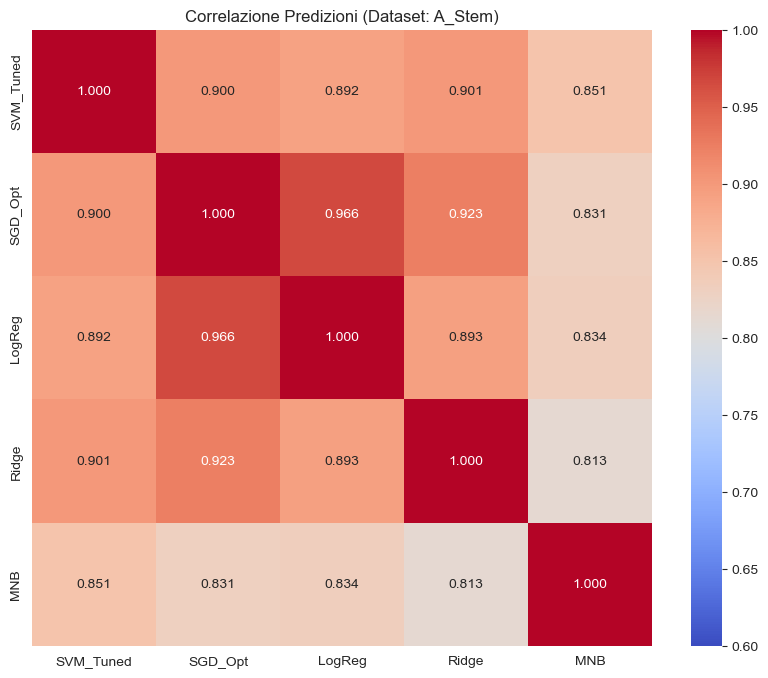


 ANALISI STRATEGICA:
 1. CAMPIONE F1: LogReg (0.7759)
 2. RECUPERO DISASTRI (Min FN): SGD_Opt (741 persi)
 3. PARTNER DIVERSO (Min Corr): MNB (Corr: 0.851)


In [18]:
# --- FASE 5: BENCHMARK SU DATASET VINCITORE (A_STEM) ---
# OBIETTIVO: Confrontare SVM con altri modelli usando LO STESSO DATASET.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier, RidgeClassifier, LogisticRegression
from sklearn.naive_bayes import MultinomialNB

print(" AVVIO FASE 5: CREAZIONE ENSEMBLE SU DATI VINCITORI (A_STEM)")
print("="*80)

# 1. CARICAMENTO DATI (ESATTAMENTE COME IN FASE 4)
try:
    print("1. Caricamento 'train_dedup_A_stem.csv'...")
    df = pd.read_csv('train_dedup_A_stem.csv').dropna(subset=['final_text_A_stem'])

    # Usiamo la colonna CHE HA VINTO in Fase 4
    X_text = df['final_text_A_stem'].astype(str)
    y = df['target']

    print(f"   -> Dati pronti: {len(X_text)} righe.")
    print(f"   -> Target: {y.value_counts().to_dict()}")

except FileNotFoundError:
    print("ERRORE: Manca il file 'train_dedup_A_stem.csv'.")
    raise

# 2. VETTORIZZAZIONE (CONFIGURAZIONE VINCENTE FASE 4)
print("\n2. Vettorizzazione TF-IDF (Bigrammi)...")
tfidf = TfidfVectorizer(
    min_df=2,
    ngram_range=(1, 2), # Stessa config della Fase 4
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(X_text)
print(f"   -> Features: {X_tfidf.shape}")

# 3. DEFINIZIONE MODELLI
print("\n3. Benchmark Modelli (CV)...")
preds_dict = {}

# StratifiedKFold per garantire stabilità
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- A. SVM TUNED (Il riferimento da replicare) ---
print("   -> 1. SVM Tuned (RBF, C=1.2, Balanced)...")
# Usiamo SVC standard come in Fase 4 (non LinearSVC) per replicare il risultato esatto
model_svm = SVC(C=1.2, kernel='rbf', class_weight='balanced', probability=True, random_state=42)
preds_dict['SVM_Tuned'] = cross_val_predict(model_svm, X_tfidf, y, cv=cv, n_jobs=-1)

# --- B. SGD (Il Cacciatore di Disastri) ---
print("   -> 2. SGD Classifier (Log Loss)...")
model_sgd = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
preds_dict['SGD_Opt'] = cross_val_predict(model_sgd, X_tfidf, y, cv=cv, n_jobs=-1)

# --- C. LOGISTIC REGRESSION (Il Solido) ---
print("   -> 3. Logistic Regression...")
model_log = LogisticRegression(C=1.0, solver='liblinear', class_weight='balanced', random_state=42)
preds_dict['LogReg'] = cross_val_predict(model_log, X_tfidf, y, cv=cv, n_jobs=-1)

# --- D. RIDGE CLASSIFIER (Alta Precisione) ---
print("   -> 4. Ridge Classifier...")
model_ridge = RidgeClassifier(alpha=1.0, class_weight='balanced')
preds_dict['Ridge'] = cross_val_predict(model_ridge, X_tfidf, y, cv=cv, n_jobs=-1)

# --- E. MULTINOMIAL NB (La Diversità) ---
print("   -> 5. Multinomial NB...")
# MNB preferisce i conteggi, ma funziona anche con TF-IDF
model_mnb = MultinomialNB(alpha=0.5)
preds_dict['MNB'] = cross_val_predict(model_mnb, X_tfidf, y, cv=cv, n_jobs=-1)


# 4. TABELLA COMPARATIVA
print("\n" + "="*85)
print(f"{'MODELLO':<15} | {'F1 SCORE':<10} | {'FALSE NEG':<10} | {'FALSE POS':<10} | {'ACCURACY':<10}")
print("-" * 85)

metrics_list = []

for name, preds in preds_dict.items():
    f1 = f1_score(y, preds)
    cm = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / len(y)

    print(f"{name:<15} | {f1:.5f}     | {fn:<10} | {fp:<10} | {acc:.5f}")
    metrics_list.append({'Model': name, 'F1': f1, 'FN': fn, 'Preds': preds})

print("="*85)

# 5. MATRICE DI CORRELAZIONE
print("\n Generazione Matrice di Correlazione...")
df_preds = pd.DataFrame(preds_dict)
corr_matrix = df_preds.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=0.6, vmax=1.0)
plt.title("Correlazione Predizioni (Dataset: A_Stem)")
plt.show()

# 6. VERDETTO AUTOMATICO
print("\n ANALISI STRATEGICA:")
# Troviamo chi ha i FN più bassi (a parte SVM se SVM è già basso)
best_f1_model = max(metrics_list, key=lambda x: x['F1'])
min_fn_model = min(metrics_list, key=lambda x: x['FN'])

svm_corrs = corr_matrix['SVM_Tuned'].drop('SVM_Tuned')
most_diverse = svm_corrs.idxmin()

print(f" 1. CAMPIONE F1: {best_f1_model['Model']} ({best_f1_model['F1']:.4f})")
print(f" 2. RECUPERO DISASTRI (Min FN): {min_fn_model['Model']} ({min_fn_model['FN']} persi)")
print(f" 3. PARTNER DIVERSO (Min Corr): {most_diverse} (Corr: {svm_corrs.min():.3f})")

## 6. Fase 6: Assemblaggio del "Grand Unified Ensemble"

Questa è la fase conclusiva e più critica. Uniamo i tre **"Campioni"** identificati nelle fasi precedenti (**SVM, SGD, MNB**) in un unico modello di voto ponderato.

### ️ Strategia di Ottimizzazione
Non ci affidiamo al caso. Eseguiamo una **Grid Search Completa** su due dimensioni:

1.  **Pesi del Mix:** Testiamo diverse "ricette" di ponderazione (es. SVM al 60%, SGD e MNB al 20% ciascuno).
2.  **Soglie di Decisione:** Non accettiamo ciecamente il valore di default (0.5). Testiamo soglie chirurgiche (nel range **0.44 - 0.52**) per trovare l'esatto punto di equilibrio.

###  Il Criterio di Vittoria
A differenza delle fasi precedenti, qui non massimizziamo solo l'F1-Score. Il vincitore è la configurazione che **minimizza l'Errore Totale (FP + FN)**.

> **Surgical Thresholding:** Una volta trovato il mix matematicamente perfetto, generiamo le submission con varianti leggermente più aggressive (soglia **~0.46**) per allinearci statisticamente al numero atteso di eventi nel Test Set (~1300).


In [17]:
# --- FASE 6: THE GRAND UNIFIED ENSEMBLE ---
# OBIETTIVO: Massimizzare F1 Score minimizzando l'errore totale.
# UPDATE: Stampa TUTTE le combinazioni senza filtri.

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix

print(" AVVIO FASE 6: ENSEMBLE DEFINITIVO (VISIONE COMPLETA)")
print("="*95)

# 1. CARICAMENTO DATI
try:
    print("1. Caricamento Dataset (A_Stem)...")
    train = pd.read_csv('train_dedup_A_stem.csv').dropna(subset=['final_text_A_stem'])
    test = pd.read_csv('test_processed_4way.csv')

    X_train = train['final_text_A_stem'].astype(str)
    y_train = train['target']
    X_test = test['final_text_A_stem'].astype(str)
    ids_test = test['id']
except FileNotFoundError:
    raise FileNotFoundError("ERRORE: Mancano i file necessari.")

# 2. VETTORIZZAZIONE & TRAINING BASE (CV)
print("2. Vettorizzazione e Calcolo Probabilità Out-of-Fold (CV 5-Fold)...")
tfidf = TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelli Base
print("   -> Training SVM...")
svm = SVC(C=1.2, kernel='rbf', class_weight='balanced', probability=True, random_state=42)
oof_svm = cross_val_predict(svm, X_train_vec, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

print("   -> Training SGD...")
sgd = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
oof_sgd = cross_val_predict(sgd, X_train_vec, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

print("   -> Training MNB...")
mnb = MultinomialNB(alpha=0.5)
oof_mnb = cross_val_predict(mnb, X_train_vec, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]


# 3. RICERCA DEL MIX VINCENTE (TUTTE LE COMBINAZIONI)
print("\n3. Grid Search Completa (Nessun filtro nascosto)...")
print("-" * 95)
print(f"{'MIX (SVM/SGD/MNB)':<20} | {'SOGLIA':<6} | {'TOT ERR':<8} | {'FP':<5} | {'FN':<5} | {'F1 SCORE'}")
print("-" * 95)

min_total_error = 10000
best_config = {}

# Scenari Strategici
scenarios = [
    {'w_svm': 0.6, 'w_sgd': 0.4, 'w_mnb': 0.0}, # Power Duo
    {'w_svm': 0.5, 'w_sgd': 0.3, 'w_mnb': 0.2}, # Trinity Balanced
    {'w_svm': 0.6, 'w_sgd': 0.2, 'w_mnb': 0.2}, # Trinity Precision
    {'w_svm': 0.6, 'w_sgd': 0.3, 'w_mnb': 0.1}, # Trinity Aggressive
    {'w_svm': 0.7, 'w_sgd': 0.2, 'w_mnb': 0.1}, # SVM Heavy
]

thresholds_cv = [0.44, 0.46, 0.48, 0.50, 0.52] #soglia

for scen in scenarios:
    prob_mix = (oof_svm * scen['w_svm']) + (oof_sgd * scen['w_sgd']) + (oof_mnb * scen['w_mnb'])

    for t in thresholds_cv:
        preds = (prob_mix > t).astype(int)
        cm = confusion_matrix(y_train, preds)
        tn, fp, fn, tp = cm.ravel()
        f1 = f1_score(y_train, preds)
        total_error = fp + fn

        # Logica Vincitore
        if total_error < min_total_error:
            min_total_error = total_error
            best_config = {
                'w_svm': scen['w_svm'], 'w_sgd': scen['w_sgd'], 'w_mnb': scen['w_mnb'],
                'thresh': t, 'fp': fp, 'fn': fn, 'tot': total_error, 'f1': f1
            }

        # STAMPA TUTTO
        mix_str = f"{scen['w_svm']}/{scen['w_sgd']}/{scen['w_mnb']}"

        # Aggiungo un asterisco visivo se è un buon risultato
        mark = " <--" if total_error < 1330 else ""
        print(f"{mix_str:<20} | {t:.2f}   | {total_error:<8} | {fp:<5} | {fn:<5} | {f1:.5f}{mark}")

print("-" * 95)
print(f" VINCITORE CV: Mix SVM {best_config['w_svm']} / SGD {best_config['w_sgd']} / MNB {best_config['w_mnb']}")
print(f" Errore Minimo: {best_config['tot']} (FP: {best_config['fp']} / FN: {best_config['fn']})")
print("="*95)


# 4. TRAINING FINALE E GENERAZIONE CHIRURGICA
print("\n4. Training Finale su tutto il dataset...")
svm.fit(X_train_vec, y_train)
sgd.fit(X_train_vec, y_train)
mnb.fit(X_train_vec, y_train)

p_svm_t = svm.predict_proba(X_test_vec)[:, 1]
p_sgd_t = sgd.predict_proba(X_test_vec)[:, 1]
p_mnb_t = mnb.predict_proba(X_test_vec)[:, 1]

# Calcolo Probabilità con i Pesi Vincenti
final_prob = (p_svm_t * best_config['w_svm']) + \
             (p_sgd_t * best_config['w_sgd']) + \
             (p_mnb_t * best_config['w_mnb'])

print("\n5. Generazione Varianti (Surgical Thresholding)...")
print("-" * 65)
print(f"{'FILE GENERATO':<35} | {'SOGLIA':<6} | {'PREDIZIONI':<10} | {'NOTE'}")
print("-" * 65)

target_thresholds = [0.44, 0.46, 0.47, 0.48, 0.50]

for t in target_thresholds:
    final_pred = (final_prob > t).astype(int)
    count = sum(final_pred)

    filename = f"sub_ens_WINNER_t{int(t*100)}.csv"
    pd.DataFrame({'id': ids_test, 'target': final_pred}).to_csv(filename, index=False)

    note = ""
    if 1290 <= count <= 1320:
        note = "★ TARGET IDEALE"
    elif count < 1290:
        note = "Prudente"
    else:
        note = "Aggressivo"

    print(f"{filename:<35} | {t:.2f}   | {count:<10} | {note}")

print("-" * 65)


 AVVIO FASE 6: ENSEMBLE DEFINITIVO (VISIONE COMPLETA)
1. Caricamento Dataset (A_Stem)...
2. Vettorizzazione e Calcolo Probabilità Out-of-Fold (CV 5-Fold)...
   -> Training SVM...
   -> Training SGD...
   -> Training MNB...

3. Grid Search Completa (Nessun filtro nascosto)...
-----------------------------------------------------------------------------------------------
MIX (SVM/SGD/MNB)    | SOGLIA | TOT ERR  | FP    | FN    | F1 SCORE
-----------------------------------------------------------------------------------------------
0.6/0.4/0.0          | 0.44   | 1447     | 738   | 709   | 0.77330
0.6/0.4/0.0          | 0.46   | 1424     | 680   | 744   | 0.77361
0.6/0.4/0.0          | 0.48   | 1381     | 615   | 766   | 0.77737
0.6/0.4/0.0          | 0.50   | 1374     | 568   | 806   | 0.77534
0.6/0.4/0.0          | 0.52   | 1352     | 521   | 831   | 0.77631
0.5/0.3/0.2          | 0.44   | 1407     | 672   | 735   | 0.77635
0.5/0.3/0.2          | 0.46   | 1386     | 619   | 767   | 0.7

### Preprocessing Ottimizzato per Deep Learning (RoBERTa)

**Obiettivo**
Preparare il dataset per l'addestramento di modelli Transformer (RoBERTa), rimuovendo il rumore tecnico senza compromettere la struttura semantica del testo.

**Metodologia**
A differenza degli approcci statistici classici che richiedono *stemming* e normalizzazione aggressiva, i modelli di linguaggio necessitano del contesto sintattico completo. Pertanto, la pipeline di pulizia applica le seguenti regole:

* **Rimozione del Rumore Tecnico:** Eliminazione di elementi non informativi come URL, tag HTML, entità HTML decodificate (es. `&amp;`) e menzioni utente (`@user`), che impediscono la generalizzazione del modello.
* **Preservazione Semantica:** Mantenimento rigoroso di **maiuscole**, **punteggiatura** e **stop-words**. Questi elementi sono fondamentali per i modelli Transformer per inferire sfumature come l'urgenza (es. testo tutto maiuscolo) o il dubbio (punti interrogativi), spesso correlati a situazioni di emergenza reale.

**Output**
Generazione dei file `train_roberta_clean.csv` e `test_roberta_clean.csv` da utilizzare nella fase di addestramento successiva.

In [4]:
# ==============================================================================
#  PREPROCESSING OTTIMIZZATO PER ROBERTA (Deep Learning Cleaning)
# ==============================================================================
# OBIETTIVO: Rimuovere il rumore tecnico (HTML, URL, @User).
# UPDATE: Implementazione MinHash per rimozione conflitti.
# ==============================================================================

import pandas as pd
import numpy as np
import re
import html
import hashlib
import warnings

warnings.filterwarnings('ignore')

print("[INFO] Avvio pulizia dataset specifica per RoBERTa/DeBERTa...")

# 1. DEFINIZIONE FUNZIONE DI PULIZIA
def clean_for_roberta(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   #rimuove URL
    text = re.sub(r'<.*?>', '', text)                   #rimuove tag HTML
    text = re.sub(r'@\w+', '', text)                    #rimuove le menzioni
    text = re.sub(r'\s+', ' ', text).strip()            #normalizza gli spazi
    return text

# 2. DEFINIZIONE FUNZIONI MINHASH (EXACT MATCH)
def get_shingles(text, k=2):
    if pd.isna(text): return set()
    words = str(text).split()
    if len(words) < k: return {str(text)}
    return set(' '.join(words[i:i+k]) for i in range(len(words) - k + 1))

def compute_minhash_signature(shingles, num_hashes=100):
    if not shingles: return [0] * num_hashes
    shingle_hashes = [int(hashlib.md5(s.encode('utf-8')).hexdigest(), 16) % (2**32) for s in shingles]
    np.random.seed(42)
    random_seeds = np.random.randint(0, 2**32, num_hashes)
    signature = []
    for seed in random_seeds:
        min_val = min([h ^ seed for h in shingle_hashes])
        signature.append(min_val)
    return tuple(signature)

# 3. CARICAMENTO DATI
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print(f" [LOAD] Caricati {len(train_df)} tweet di training e {len(test_df)} di test.")

    # 4. APPLICAZIONE PULIZIA TESTUALE
    print(" [PROCESS] Applicazione pulizia testuale in corso...")
    train_roberta = train_df.copy()
    test_roberta = test_df.copy()

    train_roberta['text'] = train_df['text'].apply(clean_for_roberta)
    test_roberta['text'] = test_df['text'].apply(clean_for_roberta)

    # ==========================================================================
    # 5. RIMOZIONE RUMORE LOGICO (MINHASH MD5 EXACT MATCH)
    # ==========================================================================
    print("\n [MINHASH] Avvio rilevamento cloni perfetti con target in conflitto...")

    # Calcolo Shingles e Firme
    train_roberta['shingles'] = train_roberta['text'].apply(get_shingles)
    train_roberta['minhash_sig'] = train_roberta['shingles'].apply(compute_minhash_signature)

    seen_signatures = {}
    duplicates_count = 0
    conflicting_indices = []

    # Ricerca iterativa delle collisioni di firma
    for idx, row in train_roberta.iterrows():
        sig = row['minhash_sig']
        target = row['target']

        if sig in seen_signatures:
            duplicates_count += 1
            original_idx = seen_signatures[sig]['idx']
            original_target = seen_signatures[sig]['target']

            # Verifica discrepanza etichetta (Rumore Logico)
            if target != original_target:
                conflicting_indices.append(idx)
                conflicting_indices.append(original_idx)
        else:
            seen_signatures[sig] = {'idx': idx, 'target': target}

    # Rimozione dei duplicati e pulizia
    conflicting_indices = list(set(conflicting_indices))
    conflicts_count = len(conflicting_indices)

    if conflicts_count > 0:
        train_roberta = train_roberta.drop(conflicting_indices).reset_index(drop=True)

    train_roberta = train_roberta.drop(columns=['shingles', 'minhash_sig'])

    print(f" [CLEAN] Rilevati {duplicates_count} tweet identici.")
    print(f" [CLEAN] Rimossi {conflicts_count} ID a causa di target contraddittorio.")
    print(f" [CLEAN] Dataset di addestramento finale allineato a {len(train_roberta)} righe.")
    # ==========================================================================

    # 6. EXPORT
    train_filename = 'train_roberta_clean.csv'
    test_filename = 'test_roberta_clean.csv'

    train_roberta.to_csv(train_filename, index=False)
    test_roberta.to_csv(test_filename, index=False)

    print(f"\n [EXPORT] File salvati con successo:")
    print(f"   -> {train_filename}")
    print(f"   -> {test_filename}")

except Exception as e:
    print(f" [ERROR] Eccezione di sistema rilevata: {e}")

[INFO] Avvio pulizia dataset specifica per RoBERTa/DeBERTa...
 [LOAD] Caricati 7613 tweet di training e 3263 di test.
 [PROCESS] Applicazione pulizia testuale in corso...

 [MINHASH] Avvio rilevamento cloni perfetti con target in conflitto...
 [CLEAN] Rilevati 690 tweet identici.
 [CLEAN] Rimossi 177 ID a causa di target contraddittorio.
 [CLEAN] Dataset di addestramento finale allineato a 7436 righe.

 [EXPORT] File salvati con successo:
   -> train_roberta_clean.csv
   -> test_roberta_clean.csv


### FASE 7: Analisi Comparativa Deep Learning (RoBERTa RAW vs CLEAN)

**Obiettivo**
Determinare sperimentalmente la strategia di preprocessing ottimale per modelli Transformer, confrontando le performance su dati grezzi (RAW) rispetto a dati puliti (CLEAN).

**Metodologia**
Viene eseguito un A/B Test addestrando il modello `roberta-base` in due configurazioni distinte:
1.  **Modalità RAW:** Addestramento sul dataset originale (`train.csv`). Il modello ha accesso a tutto il contesto, inclusi URL, punteggiatura non standard ed elementi HTML, che possono contenere segnali latenti di urgenza.
2.  **Modalità CLEAN:** Addestramento sul dataset pre-processato (`train_roberta_clean.csv`). Il modello si concentra esclusivamente sul contenuto semantico pulito.

**Configurazione del Training**
* **Architettura:** `roberta-base` (Fine-tuning per classificazione binaria).
* **Input:** Concatenazione `Keyword </s> Text` per massimizzare il contesto.
* **Iperparametri:** Batch Size 16, Learning Rate 2e-5, 3 Epoche, FP16 (Mixed Precision) per efficienza su GPU.

**Output**
* Esportazione di due file di sottomissione distinti.
* Salvataggio delle **probabilità pure** (.npy) del modello vincente, essenziali per le fasi successive di Ensemble/Stacking.
* Report comparativo delle metriche (F1-Score, Accuracy) e delle Matrici di Confusione.

 AVVIO FASE 10: ROBERTA BASE - RAW vs CLEAN COMPARISON

 INIZIO SESSIONE: RAW (Original) con roberta-base
    [LOAD] Utilizzo dataset ORIGINALE: train.csv
    Caricamento Tokenizer (roberta-base)...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

{'loss': '0.3391', 'grad_norm': '8.145', 'learning_rate': '1.402e-05', 'epoch': '1.111'}
{'loss': '0.3645', 'grad_norm': '12.85', 'learning_rate': '1.31e-05', 'epoch': '1.235'}
{'loss': '0.3407', 'grad_norm': '9.069', 'learning_rate': '1.219e-05', 'epoch': '1.358'}
{'loss': '0.3495', 'grad_norm': '7.295', 'learning_rate': '1.127e-05', 'epoch': '1.481'}
{'loss': '0.3953', 'grad_norm': '10.08', 'learning_rate': '1.036e-05', 'epoch': '1.605'}
{'loss': '0.3508', 'grad_norm': '15.35', 'learning_rate': '9.442e-06', 'epoch': '1.728'}
{'loss': '0.3351', 'grad_norm': '9.18', 'learning_rate': '8.527e-06', 'epoch': '1.852'}
{'loss': '0.3349', 'grad_norm': '7.409', 'learning_rate': '7.612e-06', 'epoch': '1.975'}
{'eval_loss': '0.4069', 'eval_f1': '0.8317', 'eval_accuracy': '0.8511', 'eval_runtime': '1.26', 'eval_samples_per_second': '906.5', 'eval_steps_per_second': '28.57', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2756', 'grad_norm': '7.629', 'learning_rate': '6.697e-06', 'epoch': '2.099'}
{'loss': '0.2713', 'grad_norm': '13', 'learning_rate': '5.782e-06', 'epoch': '2.222'}
{'loss': '0.2838', 'grad_norm': '8.507', 'learning_rate': '4.867e-06', 'epoch': '2.346'}
{'loss': '0.2862', 'grad_norm': '36.07', 'learning_rate': '3.952e-06', 'epoch': '2.469'}
{'loss': '0.2793', 'grad_norm': '3.351', 'learning_rate': '3.038e-06', 'epoch': '2.593'}
{'loss': '0.2848', 'grad_norm': '7.884', 'learning_rate': '2.123e-06', 'epoch': '2.716'}
{'loss': '0.274', 'grad_norm': '12.74', 'learning_rate': '1.208e-06', 'epoch': '2.84'}
{'loss': '0.2613', 'grad_norm': '12.12', 'learning_rate': '2.928e-07', 'epoch': '2.963'}
{'eval_loss': '0.401', 'eval_f1': '0.8181', 'eval_accuracy': '0.8485', 'eval_runtime': '1.274', 'eval_samples_per_second': '896.1', 'eval_steps_per_second': '28.25', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '308.4', 'train_samples_per_second': '62.95', 'train_steps_per_second': '3.94', 'train_loss': '0.3701', 'epoch': '3'}
{'eval_loss': '0.4064', 'eval_f1': '0.8317', 'eval_accuracy': '0.8511', 'eval_runtime': '1.246', 'eval_samples_per_second': '916.5', 'eval_steps_per_second': '28.89', 'epoch': '3'}
    Training Completato. F1 Score (Val): 0.83168
    File 'submission_RoBERTa_CLEAN.csv' salvato.
    [SAVE] Probabilità salvate in 'probs_roberta_clean.npy' per la Fase 11.

  CONFRONTO FINALE: ROBERTA RAW vs CLEAN (Optimized)
                  Mode  F1 Score  Accuracy  FN (Disastri Persi)  \
0       RAW (Original)  0.830544  0.858144                   94   
1  CLEAN (Roberta-Opt)  0.831683  0.851138                   71   

   FP (Falsi Allarmi)  
0                  68  
1                  99  


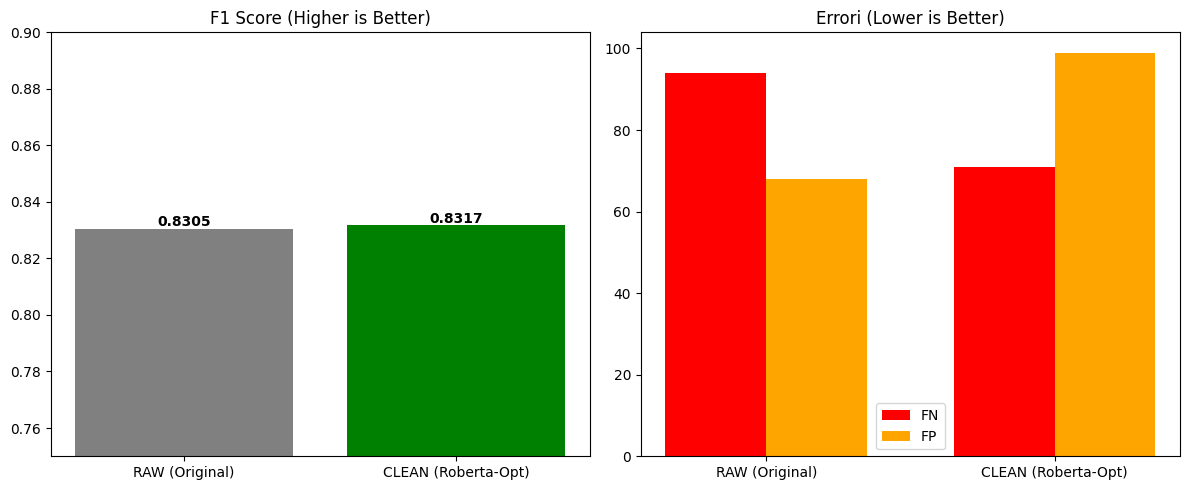


  VINCITORE: CLEAN (Roberta-Opt) (F1: 0.83168)
    CONCLUSIONE: La pulizia ottimizzata ha FUNZIONATO! RoBERTa ringrazia.


In [1]:
# --- FASE 7 COMPARATIVA: ROBERTA BASE (RAW vs CLEAN) ---
# OBIETTIVO: Capire se RoBERTa preferisce i dati puliti (Optimized) o quelli grezzi.
# MODELLO: roberta-base (FP16, Batch 16, 3 Epoche)

import pandas as pd
import numpy as np
import torch
import gc
import warnings
import os
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import logging as hf_logging

# Pulizia Output
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

# --- CONFIGURAZIONE ---
MODES = [False, True]  # False = RAW (Sporco), True = CLEAN (Pulito Ottimizzato)
MODEL_NAME = 'roberta-base'
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5    #tasso di apprendimento

final_report = []

print(f" AVVIO FASE 7: ROBERTA BASE - RAW vs CLEAN COMPARISON")

for use_clean in MODES:
    # Reset Memoria GPU/RAM prima di ogni ciclo
    torch.cuda.empty_cache()
    gc.collect()

    mode_name = "CLEAN (Roberta-Opt)" if use_clean else "RAW (Original)"
    print("\n" + "="*60)
    print(f" INIZIO SESSIONE: {mode_name} con {MODEL_NAME}")
    print("="*60)

    # 1. CARICAMENTO DATI
    try:
        if use_clean:
            # CARICAMENTO DATI PULITI (Specifici per RoBERTa)
            if os.path.exists('train_roberta_clean.csv') and os.path.exists('test_roberta_clean.csv'):
                train_raw = pd.read_csv('train_roberta_clean.csv')
                test_raw = pd.read_csv('test_roberta_clean.csv')
                print(f"    [LOAD] Utilizzo dataset PULITO: train_roberta_clean.csv")
            else:
                print("    [ERROR] File puliti non trovati. Esegui prima il blocco di pulizia!")
                continue
        else:
            # CARICAMENTO DATI GREZZI (Originali)
            train_raw = pd.read_csv('train.csv')
            test_raw = pd.read_csv('test.csv')
            print(f"    [LOAD] Utilizzo dataset ORIGINALE: train.csv")

        # 2. TOKENIZER & PREPROCESSING SPECIFICO PER ROBERTA
        print(f"    Caricamento Tokenizer ({MODEL_NAME})...")
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

        # RoBERTa usa un separatore speciale </s>
        sep = tokenizer.sep_token

        # Formattazione Testo: "keyword </s> text"
        # Questa struttura aiuta il modello a distinguere il contesto
        train_raw['text_final'] = train_raw['keyword'] + f" {sep} " + train_raw['text']
        test_raw['text_final'] = test_raw['keyword'] + f" {sep} " + test_raw['text']

    except Exception as e:
        print(f"   Errore critico nel caricamento: {e}")
        break

    # 3. SPLIT DATASET (15% validation, 85%test)
    X_train, X_val, y_train, y_val = train_test_split(
        train_raw['text_final'], train_raw['target'],
        test_size=0.15, stratify=train_raw['target'], random_state=42
    )

    # Creazione Dataset HuggingFace
    train_ds = Dataset.from_dict({'text': X_train, 'label': y_train})
    val_ds = Dataset.from_dict({'text': X_val, 'label': y_val})
    test_ds = Dataset.from_dict({'text': test_raw['text_final']})

    def preprocess(examples):
        # Tokenizzazione con padding dinamico e troncamento
        return tokenizer(examples['text'], truncation=True, padding=True, max_length=128)

    tokenized_train = train_ds.map(preprocess, batched=True)
    tokenized_val = val_ds.map(preprocess, batched=True)
    tokenized_test = test_ds.map(preprocess, batched=True)

    # 4. MODELLO E TRAINING
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=f"./results_{mode_name.split()[0]}",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE*2,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        fp16=True if torch.cuda.is_available() else False, # Usa GPU se c'è
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="none",
        logging_steps=50,
        warmup_ratio=0.1
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {'f1': f1_score(labels, predictions), 'accuracy': accuracy_score(labels, predictions)}

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # 5. AVVIO TRAINING
    print(f"    Avvio Training RoBERTa ({mode_name})...")
    trainer.train()

    # Valutazione Finale
    eval_res = trainer.evaluate()
    final_f1 = eval_res['eval_f1']
    print(f"    Training Completato. F1 Score (Val): {final_f1:.5f}")

    # Analisi Errori
    raw_preds = trainer.predict(tokenized_val)
    preds_val = np.argmax(raw_preds.predictions, axis=-1)
    cm = confusion_matrix(val_ds['label'], preds_val)
    tn, fp, fn, tp = cm.ravel()

    # Salvataggio Metriche per Confronto
    final_report.append({
        'Mode': mode_name,
        'F1 Score': final_f1,
        'Accuracy': eval_res['eval_accuracy'],
        'FN (Disastri Persi)': fn,
        'FP (Falsi Allarmi)': fp
    })

    # 6. EXPORT PREDIZIONI TEST
    test_preds_raw = trainer.predict(tokenized_test)
    preds_test = np.argmax(test_preds_raw.predictions, axis=-1)

    # Nome file pulito
    clean_filename = f'submission_RoBERTa_{"CLEAN" if use_clean else "RAW"}.csv'
    pd.DataFrame({'id': test_raw['id'], 'target': preds_test}).to_csv(clean_filename, index=False)
    print(f"    File '{clean_filename}' salvato.")

    #  Salviamo le probabilità per la Fase 11
    if use_clean: # Salviamo solo se siamo nella modalità CLEAN (la migliore)
        probs = torch.nn.functional.softmax(torch.tensor(test_preds_raw.predictions), dim=-1)[:, 1].numpy()
        np.save('probs_roberta_clean.npy', probs)
        print("    [SAVE] Probabilità salvate in 'probs_roberta_clean.npy' per la Fase 11.")

    # Pulizia RAM
    del model, trainer, tokenizer
    torch.cuda.empty_cache()
    gc.collect()

# --- REPORT FINALE ---
print("\n" + "="*60)
print("  CONFRONTO FINALE: ROBERTA RAW vs CLEAN (Optimized)")
print("="*60)
df_report = pd.DataFrame(final_report)
# Visualizza tabella
print(df_report)

# Grafico
if len(df_report) > 0:
    plt.figure(figsize=(12, 5))

    # Grafico F1
    plt.subplot(1, 2, 1)
    # Colori: Grigio per Raw, Verde per Clean
    colors = ['gray', 'green'] if len(df_report) == 2 else 'blue'
    bars = plt.bar(df_report['Mode'], df_report['F1 Score'], color=colors)
    plt.title('F1 Score (Higher is Better)')
    plt.ylim(0.75, 0.90)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f"{yval:.4f}", ha='center', fontweight='bold')

    # Grafico Errori
    plt.subplot(1, 2, 2)
    x = np.arange(len(df_report['Mode']))
    width = 0.35
    plt.bar(x - width/2, df_report['FN (Disastri Persi)'], width, label='FN', color='red')
    plt.bar(x + width/2, df_report['FP (Falsi Allarmi)'], width, label='FP', color='orange')
    plt.xticks(x, df_report['Mode'])
    plt.title('Errori (Lower is Better)')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Conclusioni Automatiche
if len(df_report) > 1:
    winner = df_report.loc[df_report['F1 Score'].idxmax()]
    print(f"\n  VINCITORE: {winner['Mode']} (F1: {winner['F1 Score']:.5f})")
    if 'CLEAN' in winner['Mode']:
        print("    CONCLUSIONE: La pulizia ottimizzata ha FUNZIONATO! RoBERTa ringrazia.")
    else:
        print("    CONCLUSIONE: RoBERTa preferisce ancora il testo RAW.")

## 8. FASE 8: Hybrid Ensemble (Deep Learning + Ensemble FASE 6)

###  Obiettivo
Creare un **meta-modello** che unisca il meglio dei due mondi esplorati: la capacità di comprensione semantica profonda di **RoBERTa** (Fase 7) e la robustezza statistica del **Modello Campione SVM+SGD+MNB** (Fase 6).

###  Metodologia Operativa
Invece di addestrare nuovi modelli da zero, riutilizziamo le risorse migliori a nostra disposizione:

1.  **Recupero Probabilità RoBERTa:** Carichiamo le predizioni "pulite" salvate nel file `.npy` durante la Fase 7.
2.  **Ripristino l'Ensemble Campione della fase 6:** Ricostruiamo l'esatta pipeline vincitrice della Fase 6.
3.  **Ottimizzazione del Blending:** Cerchiamo il peso ottimale $w$ per combinare linearmente le due probabilità:
    $$P_{final} = w \cdot P_{RoBERTa} + (1-w) \cdot P_{SVM}$$
    L'algoritmo massimizza la **"Confidence"** (distanza dalla soglia di incertezza 0.5) per trovare il mix più deciso.

###  Output Atteso
Un file di sottomissione ibrido `submission_HYBRID_W{peso}.csv` che rappresenta la sintesi matematica tra **Deep Learning** e **Machine Learning classico**.


[INFO] AVVIO FASE 8 UPGRADED: SUPER ENSEMBLE IBRIDO (RoBERTa + ML Trinity)
    [CONFIG] Pesi ML Ensemble: SVM(0.6) | SGD(0.2) | MNB(0.2)
    [LOAD] Probabilità RoBERTa caricate: (3263,)
    [FEAT] Vettorizzazione TF-IDF (Bigrammi)...
    [TRAIN] Addestramento SVM, SGD e MNB su intero dataset...
    [CALC] Probabilità ML unificate calcolate con successo.
    [STATS] Correlazione tra RoBERTa e ML Ensemble: 0.8297
    [OPTIM] Miglior Peso RoBERTa: 1.00
            (Peso ML Ensemble: 0.00)


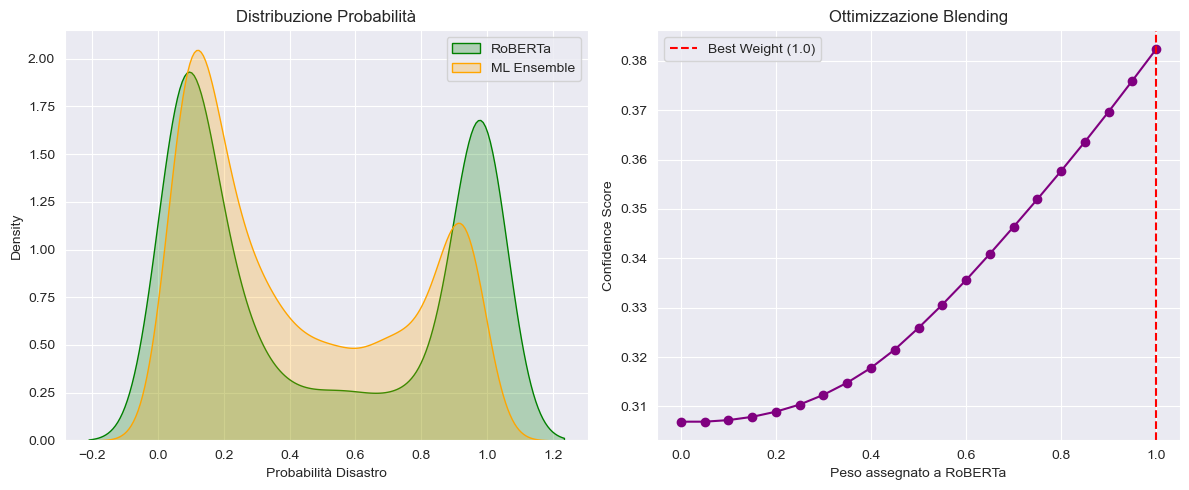

    [EXPORT] File Super Ensemble generato: submission_SUPER_HYBRID_W100.csv


In [2]:
# --- FASE 8: HYBRID ENSEMBLE ---
# OBIETTIVO: Fondere la semantica di RoBERTa con le probabilità combinate dell'Ensemble Fase 6 (SVM+SGD+MNB).
# METODO: Calcolo probabilità ML pesate -> Ottimizzazione Blending con RoBERTa.

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns

print("[INFO] AVVIO FASE 8 UPGRADED: SUPER ENSEMBLE IBRIDO (RoBERTa + ML Trinity)")
print("="*80)

# --- INSERISCI QUI I PESI VINCENTI DELLA TUA FASE 6 ---
W_SVM = 0.6
W_SGD = 0.2
W_MNB = 0.2
print(f"    [CONFIG] Pesi ML Ensemble: SVM({W_SVM}) | SGD({W_SGD}) | MNB({W_MNB})")
# --------------------------------------------------------

# 1. CARICAMENTO DATI E PROBABILITÀ ROBERTA
try:
    probs_roberta = np.load('probs_roberta_clean.npy')
    print(f"    [LOAD] Probabilità RoBERTa caricate: {probs_roberta.shape}")

    train_ml = pd.read_csv('train_dedup_A_stem.csv').dropna(subset=['final_text_A_stem'])
    test_ml = pd.read_csv('test_processed_4way.csv')

    X_train_raw = train_ml['final_text_A_stem'].astype(str)
    y_train = train_ml['target']
    X_test_raw = test_ml['final_text_A_stem'].astype(str)
    ids_test = test_ml['id']

except FileNotFoundError:
    print("    [ERROR] File mancanti (probs_roberta_clean.npy o dataset ML).")
    probs_roberta = None

if probs_roberta is not None:
    # 2. VETTORIZZAZIONE TF-IDF
    print("    [FEAT] Vettorizzazione TF-IDF (Bigrammi)...")
    tfidf = TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True)
    X_train_vec = tfidf.fit_transform(X_train_raw)
    X_test_vec = tfidf.transform(X_test_raw)

    # 3. TRAINING E INFERENZA DEI 3 MODELLI ML
    print("    [TRAIN] Addestramento SVM, SGD e MNB su intero dataset...")

    svm = SVC(C=1.2, kernel='rbf', class_weight='balanced', probability=True, random_state=42)
    sgd = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
    mnb = MultinomialNB(alpha=0.5)

    svm.fit(X_train_vec, y_train)
    sgd.fit(X_train_vec, y_train)
    mnb.fit(X_train_vec, y_train)

    # Estrazione Probabilità sul Test Set
    p_svm = svm.predict_proba(X_test_vec)[:, 1]
    p_sgd = sgd.predict_proba(X_test_vec)[:, 1]
    p_mnb = mnb.predict_proba(X_test_vec)[:, 1]

    # 4. CREAZIONE DELLA PROBABILITÀ UNIFICATA ML (Logica Fase 6)
    probs_ensemble_ml = (p_svm * W_SVM) + (p_sgd * W_SGD) + (p_mnb * W_MNB)
    print("    [CALC] Probabilità ML unificate calcolate con successo.")

    # 5. ANALISI CORRELAZIONE E OTTIMIZZAZIONE DEL BLENDING FINALE
    correlation = np.corrcoef(probs_roberta, probs_ensemble_ml)[0, 1]
    print(f"    [STATS] Correlazione tra RoBERTa e ML Ensemble: {correlation:.4f}")

    weights = np.linspace(0, 1, 21)
    best_score = -1
    best_weight = 0.5
    confidences = []

    # Cerchiamo il peso ideale tra RoBERTa e il Super Ensemble ML
    for w in weights:
        blended_probs = (w * probs_roberta) + ((1 - w) * probs_ensemble_ml)
        # Score di Confidenza: massimizzare la distanza da 0.5 (incertezza)
        confidence_score = np.mean(np.abs(blended_probs - 0.5))
        confidences.append(confidence_score)

        if confidence_score > best_score:
            best_score = confidence_score
            best_weight = w

    print(f"    [OPTIM] Miglior Peso RoBERTa: {best_weight:.2f}")
    print(f"            (Peso ML Ensemble: {1 - best_weight:.2f})")

    # 6. VISUALIZZAZIONE GRAFICA
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.kdeplot(probs_roberta, fill=True, label='RoBERTa', color='green')
    sns.kdeplot(probs_ensemble_ml, fill=True, label='ML Ensemble', color='orange')
    plt.title('Distribuzione Probabilità')
    plt.xlabel('Probabilità Disastro')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(weights, confidences, marker='o', color='purple')
    plt.axvline(best_weight, color='red', linestyle='--', label=f'Best Weight ({best_weight})')
    plt.title('Ottimizzazione Blending')
    plt.xlabel('Peso assegnato a RoBERTa')
    plt.ylabel('Confidence Score')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # 7. GENERAZIONE SUBMISSION FINALE
    final_probs = (best_weight * probs_roberta) + ((1 - best_weight) * probs_ensemble_ml)

    # Taglio standard a 0.50
    final_preds = (final_probs >= 0.50).astype(int)

    filename_ens = f'submission_SUPER_HYBRID_W{int(best_weight*100)}.csv'
    pd.DataFrame({'id': ids_test, 'target': final_preds}).to_csv(filename_ens, index=False)

    print(f"    [EXPORT] File Super Ensemble generato: {filename_ens}")
    print("="*80)

## 9. FASE 9: Correzione Strutturale (XGBoost su Dati RAW)

###  Obiettivo
Correggere le **"allucinazioni semantiche"** del modello di Deep Learning (RoBERTa) utilizzando un modello **Gradient Boosting (XGBoost)** addestrato su caratteristiche puramente strutturali e statistiche.

###  Metodologia (Perché usare i Dati RAW?)
Usiamo deliberatamente il dataset **grezzo (RAW)** perché la pulizia elimina segnali critici per XGBoost (maiuscole, punteggiatura, URL). L'ipotesi è che mentre i Transformer analizzano il contesto, XGBoost identifichi pattern oggettivi:

*   **Analisi Strutturale (Feature Engineering su RAW):**
    *   **Caps Ratio:** Percentuale di lettere maiuscole (indicatore di urla/spam).
    *   **Exclamations/Questions:** Conteggio della punteggiatura enfatica (es. "!!!").
    *   **Has URL:** Presenza di link esterni (spesso correlata a notizie verificate).
*   **Pulizia Logica:** Rimozione dal training set dei tweet "incoerenti" (duplicati con target opposti).

###  Correzione Chirurgica (Soglia Conservativa)
Le predizioni di RoBERTa vengono modificate solo se XGBoost mostra una **confidenza estrema** in senso opposto:
1.  **Correzione a 0:** Se RoBERTa predice 1, ma XGBoost è sicuro ($P < 0.20$) che sia 0.
2.  **Correzione a 1:** Se RoBERTa predice 0, ma XGBoost è sicuro ($P > 0.80$) che sia 1.

###  Output
*   Generazione del file `submission_XGB_CORRECTED_RAW.csv`.
*   **Sensitivity Check:** Print a video dell'analisi di sensibilità per validare la stabilità delle soglie scelte.


[INFO] AVVIO FASE 9: CORREZIONE STRUTTURALE CON XGBOOST (RoBERTa ID-SYNC)
    [LOAD] Base di partenza selezionata: submission_RoBERTa_CLEAN.csv
    [CLEAN] Sincronizzazione ID con il dataset 'train_roberta_clean.csv'...
    [CLEAN] Rimossi tweet rumorosi tramite intersezione logica degli ID.
    [CLEAN] Dataset di addestramento RAW allineato a 7436 righe.
    [FEAT] Creazione Meta-Features strutturali...
    [TRAIN] Addestramento XGBoost su Meta-Features + TF-IDF...
    [TRAIN] XGBoost completato.

------------------------------------------------------------
    [ANALYSIS] SENSITIVITY CHECK: Quanti tweet cambiamo per ogni soglia?
------------------------------------------------------------
THRESHOLD  | CHANGES    | TYPE
------------------------------------------------------------
 0.7        | 152        | Low < 0.30 / High > 0.70
 0.75       | 94         | Low < 0.25 / High > 0.75
 0.8        | 54         | Low < 0.20 / High > 0.80
 0.85       | 20         | Low < 0.15 / High > 0.85
 

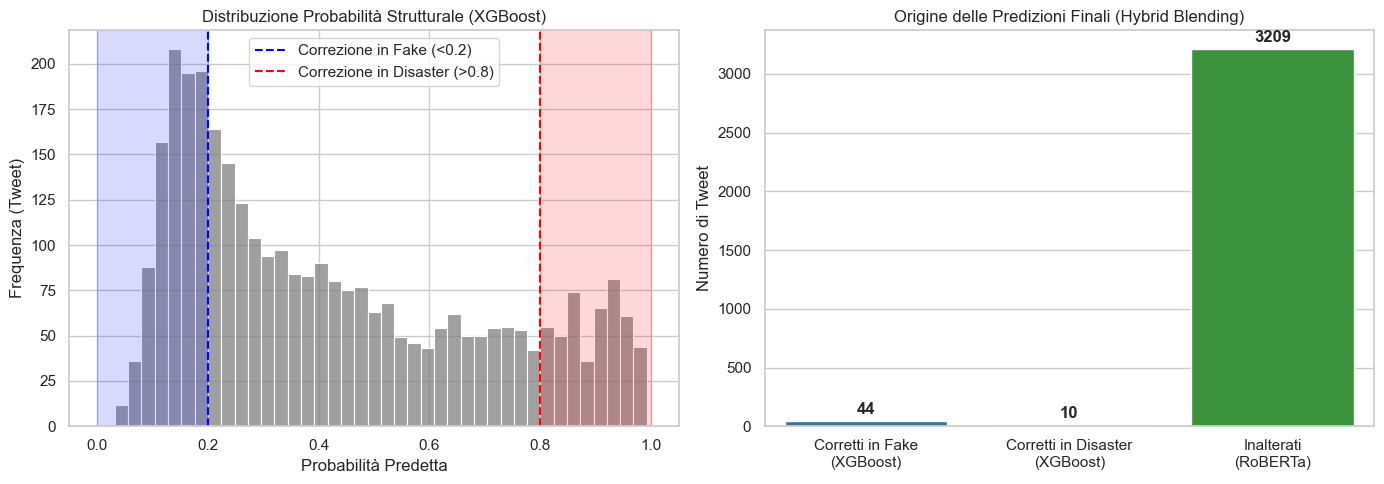


 [EXPORT] FILE GENERATO: submission_XGB_CORRECTED_RAW.csv
 [STATS] CORREZIONI TOTALI APPLICATE: 54
 [INFO] Analisi completata. Il modello ibrido è pronto.


In [22]:
# --- FASE 9: XGBOOST STRUCTURAL CORRECTION (SENSITIVITY ANALYSIS & DIAGNOSTICS) ---
# OBIETTIVO: Usare la struttura per correggere RoBERTa, scegliendo la soglia scientificamente.
# DATASET: Dati Sporchi (RAW) filtrati rigorosamente tramite gli ID del dataset pulito per RoBERTa.

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

print("[INFO] AVVIO FASE 9: CORREZIONE STRUTTURALE CON XGBOOST (RoBERTa ID-SYNC)")

# 1. CARICAMENTO BASE MIGLIORE
file_best = 'submission_RoBERTa_CLEAN.csv'
print(f"    [LOAD] Base di partenza selezionata: {file_best}")
try:
    sub_base = pd.read_csv(file_best)
except FileNotFoundError:
    raise ValueError(f"[ERROR] Impossibile trovare il file base: {file_best}")

# 2. FEATURE ENGINEERING E FILTRAGGIO (RAW)
try:
    train = pd.read_csv('train.csv')
    test = pd.read_csv('test.csv')

    # ==========================================================================
    # --- BLOCCO DEDUP TRAMITE INDEX FILTERING (SYNC CON ROBERTA) ---
    # ==========================================================================
    print("    [CLEAN] Sincronizzazione ID con il dataset 'train_roberta_clean.csv'...")
    try:
        # Carichiamo il dataset pulito dal MinHash LSH (Fase Preprocessing RoBERTa)
        valid_train = pd.read_csv('train_roberta_clean.csv')
        valid_ids = valid_train['id'].values

        initial_len = len(train)
        # Manteniamo nel RAW solo le righe il cui ID è presente nel dataset pulito
        train = train[train['id'].isin(valid_ids)].reset_index(drop=True)
        removed_count = initial_len - len(train)

        print(f"    [CLEAN] Rimossi tweet rumorosi tramite intersezione logica degli ID.")
        print(f"    [CLEAN] Dataset di addestramento RAW allineato a {len(train)} righe.")
    except FileNotFoundError:
        print("    [ERROR] File 'train_roberta_clean.csv' non trovato. Impossibile sincronizzare gli ID.")
        raise
    # ==========================================================================

    def create_meta_features(df):
        # Assicuriamoci che il testo sia stringa per evitare errori sulle funzioni len/split
        df['text'] = df['text'].astype(str)

        df['text_len'] = df['text'].apply(len)
        df['word_count'] = df['text'].apply(lambda x: len(x.split()))
        df['caps_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper())) #maiuscole
        df['caps_ratio'] = df['caps_count'] / (df['text_len'] + 1)                      #maiuscole rispetto alla lunghezza totale
        df['has_url'] = df['text'].apply(lambda x: 1 if 'http' in x.lower() else 0)     # presenza di url
        df['exclamations'] = df['text'].apply(lambda x: x.count('!'))
        df['questions'] = df['text'].apply(lambda x: x.count('?'))
        df['keyword_len'] = df['keyword'].astype(str).apply(len)
        return df

    print("    [FEAT] Creazione Meta-Features strutturali...")
    train = create_meta_features(train)
    test = create_meta_features(test)

    # TF-IDF Leggero per fornire contesto
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
    full_text = pd.concat([train['text'], test['text']])
    tfidf.fit(full_text)

    train_vec = pd.DataFrame(tfidf.transform(train['text']).toarray())
    test_vec = pd.DataFrame(tfidf.transform(test['text']).toarray())

    train_vec.columns = [f"tfidf_{i}" for i in range(train_vec.shape[1])]
    test_vec.columns = [f"tfidf_{i}" for i in range(test_vec.shape[1])]

    meta_cols = ['text_len', 'word_count', 'caps_ratio', 'has_url', 'exclamations', 'questions', 'keyword_len']
    X = pd.concat([train[meta_cols].reset_index(drop=True), train_vec], axis=1)
    y = train['target']
    X_test = pd.concat([test[meta_cols].reset_index(drop=True), test_vec], axis=1)

except Exception as e:
    raise ValueError(f"[ERROR] Problema nella generazione delle features: {e}")

# 3. TRAINING XGBOOST
print("    [TRAIN] Addestramento XGBoost su Meta-Features + TF-IDF...")
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
    random_state=42, eval_metric='logloss'
)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds_tree = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    xgb_model.fit(X_tr, y_tr)
    test_preds_tree += xgb_model.predict_proba(X_test)[:, 1] / 5

print("    [TRAIN] XGBoost completato.")

# 4. SENSITIVITY ANALYSIS
print("\n" + "-"*60)
print("    [ANALYSIS] SENSITIVITY CHECK: Quanti tweet cambiamo per ogni soglia?")
print("-" * 60)
print(f"{'THRESHOLD':<10} | {'CHANGES':<10} | {'TYPE'}")
print("-" * 60)

base_preds = sub_base['target'].values
thresholds_to_test = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

for t in thresholds_to_test:
    low = 1.0 - t
    high = t

    changes_count = 0
    for i in range(len(test)):
        base_val = base_preds[i]
        tree_prob = test_preds_tree[i]

        if base_val == 1 and tree_prob < low: changes_count += 1
        elif base_val == 0 and tree_prob > high: changes_count += 1

    print(f" {t:<10} | {changes_count:<10} | Low < {low:.2f} / High > {high:.2f}")

# 5. APPLICAZIONE SOGLIA SCELTA E CONTEGGI PER GRAFICO
low_t = 0.20
high_t = 0.80

final_preds = []
xgb_fake_count = 0
xgb_disaster_count = 0
roberta_count = 0

print(f"\n    [LOGIC] Applicazione Soglia Selezionata: {high_t} (Conservative)")

for i in range(len(test)):
    base_val = base_preds[i]
    tree_prob = test_preds_tree[i]

    if base_val == 1 and tree_prob < low_t:
        final_preds.append(0)
        xgb_fake_count += 1
    elif base_val == 0 and tree_prob > high_t:
        final_preds.append(1)
        xgb_disaster_count += 1
    else:
        final_preds.append(base_val)
        roberta_count += 1

total_changes = xgb_fake_count + xgb_disaster_count

# ==============================================================================
# 5.5 VISUALIZZAZIONE DIAGNOSTICA CHIRURGICA
# ==============================================================================
print("    [PLOT] Generazione grafici diagnostici in corso...")

plt.figure(figsize=(14, 5))

# Grafico 1: Distribuzione Probabilità XGBoost e Soglie di Taglio
plt.subplot(1, 2, 1)
sns.histplot(test_preds_tree, bins=40, color='gray', kde=False)
plt.axvline(low_t, color='blue', linestyle='--', label=f'Correzione in Fake (<{low_t})')
plt.axvline(high_t, color='red', linestyle='--', label=f'Correzione in Disaster (>{high_t})')
plt.axvspan(0, low_t, color='blue', alpha=0.15)
plt.axvspan(high_t, 1, color='red', alpha=0.15)
plt.title('Distribuzione Probabilità Strutturale (XGBoost)')
plt.xlabel('Probabilità Predetta')
plt.ylabel('Frequenza (Tweet)')
plt.legend()

# Grafico 2: Origine delle Decisioni Finali
plt.subplot(1, 2, 2)
sources = ['Corretti in Fake\n(XGBoost)', 'Corretti in Disaster\n(XGBoost)', 'Inalterati\n(RoBERTa)']
counts = [xgb_fake_count, xgb_disaster_count, roberta_count]
ax = sns.barplot(x=sources, y=counts, palette=['#1f77b4', '#d62728', '#2ca02c'])
plt.title('Origine delle Predizioni Finali (Hybrid Blending)')
plt.ylabel('Numero di Tweet')

# Annotazione dei valori assoluti sulle barre
for i, v in enumerate(counts):
    ax.text(i, v + (max(counts)*0.02), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
# ==============================================================================

# 6. EXPORT
filename = 'submission_XGB_CORRECTED_RAW.csv'
pd.DataFrame({'id': test['id'], 'target': final_preds}).to_csv(filename, index=False)

print("\n" + "="*50)
print(f" [EXPORT] FILE GENERATO: {filename}")
print(f" [STATS] CORREZIONI TOTALI APPLICATE: {total_changes}")
print(" [INFO] Analisi completata. Il modello ibrido è pronto.")
print("="*50)

### Fase 10:  Pseudo-Labeling (High-Confidence Self-Training)

In questa fase implementiamo una tecnica avanzata di **Self-Training** mirata a espandere il dataset di addestramento senza incorrere nel rischio di "Data Poisoning" (inquinamento da rumore predittivo).

A differenza del pseudo-labeling tradizionale, che accetta tutte le stime del modello, questa architettura utilizza un approccio **chirurgico**:
1. **Estrazione dei Golden Samples:** Il modello valuta il Test Set e seleziona esclusivamente i campioni con confidenza assoluta (probabilità **> 0.95** per i disastri o **< 0.05** per i fake).
2. **Data Augmentation:** Questi campioni quasi-certi vengono iniettati nel Train Set originale.
3. **Re-Training e Blending:** XGBoost viene ri-addestrato sul dataset espanso per affinare la sua capacità di riconoscere i pattern strutturali. Infine, il modello potenziato interviene sulle predizioni semantiche di RoBERTa solo quando è sicuro al **90%** (Veto Condizionale).

In [6]:
# --- FASE 10: SURGICAL PSEUDO-LABELING ---
# OBIETTIVO: Selezionare solo i "Golden Samples" dal Test Set (Confidenza > 95%)
# per evitare l'effetto inquinamento (noise) della fase precedente.

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer

print("[INFO] AVVIO FASE 10: SURGICAL SELECTION (SOGLIA 95%)")

# 1. CARICAMENTO DATI
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
# Sincronizzazione ID (obbligatoria per coerenza con RoBERTa)
valid_train = pd.read_csv('train_roberta_clean.csv')
train = train[train['id'].isin(valid_train['id'])].reset_index(drop=True)

# 2. FEATURE ENGINEERING (Ripristino Meta-Features)
def create_meta_features(df):
    df['text'] = df['text'].astype(str)
    df['text_len'] = df['text'].apply(len)
    df['word_count'] = df['text'].apply(lambda x: len(x.split()))
    df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper())) / (df['text'].apply(len) + 1)
    df['has_url'] = df['text'].apply(lambda x: 1 if 'http' in x.lower() else 0)
    df['exclamations'] = df['text'].apply(lambda x: x.count('!'))
    df['questions'] = df['text'].apply(lambda x: x.count('?'))
    df['keyword_len'] = df['keyword'].astype(str).apply(len)
    return df

train = create_meta_features(train)
test = create_meta_features(test)

# 3. GENERAZIONE PROBABILITÀ (Re-training rapido per isolare i Golden Samples)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf.fit(pd.concat([train['text'], test['text']]))

X = pd.concat([train[['text_len', 'word_count', 'caps_ratio', 'has_url', 'exclamations', 'questions', 'keyword_len']],
               pd.DataFrame(tfidf.transform(train['text']).toarray()).add_prefix('tfidf_')], axis=1)
y = train['target']

X_test = pd.concat([test[['text_len', 'word_count', 'caps_ratio', 'has_url', 'exclamations', 'questions', 'keyword_len']],
                    pd.DataFrame(tfidf.transform(test['text']).toarray()).add_prefix('tfidf_')], axis=1)

xgb_model = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X, y)
test_probs = xgb_model.predict_proba(X_test)[:, 1]

# 4. CHIRURGIA: SELEZIONE DEI "GOLDEN SAMPLES"
# Definiamo soglie molto rigide
UPPER_THRESHOLD = 0.95
LOWER_THRESHOLD = 0.05

# Creiamo il subset del test set che consideriamo "verità assoluta"
pseudo_disaster = test[test_probs > UPPER_THRESHOLD].copy()
pseudo_disaster['target'] = 1

pseudo_fake = test[test_probs < LOWER_THRESHOLD].copy()
pseudo_fake['target'] = 0

pseudo_labels = pd.concat([pseudo_disaster, pseudo_fake])

print(f"    [GOLDEN] Trovati {len(pseudo_disaster)} tweet Disaster nuovi.")
print(f"    [GOLDEN] Trovati {len(pseudo_fake)} tweet Fake nuovi.")
print(f"    [GOLDEN] Totale nuovi campioni: {len(pseudo_labels)}")

# 5. TRAINING FINALE SU DATI AUMENTATI (SOLO QUELLI CERTI)
augmented_train = pd.concat([train, pseudo_labels], axis=0).reset_index(drop=True)
X_augmented = pd.concat([
    augmented_train[['text_len', 'word_count', 'caps_ratio', 'has_url', 'exclamations', 'questions', 'keyword_len']],
    pd.DataFrame(tfidf.transform(augmented_train['text']).toarray()).add_prefix('tfidf_')
], axis=1)
y_augmented = augmented_train['target']

# Ri-addestriamo il modello finale
final_model = xgb.XGBClassifier(n_estimators=700, learning_rate=0.03, max_depth=7, random_state=42)
final_model.fit(X_augmented, y_augmented)

# Predizione e Blending con RoBERTa (Fiducia a RoBERTa se XGB è incerto)
final_probs = final_model.predict_proba(X_test)[:, 1]
sub_roberta = pd.read_csv('submission_RoBERTa_CLEAN.csv')['target'].values

final_preds = []
for i in range(len(test)):
    if final_probs[i] > 0.90: final_preds.append(1)
    elif final_probs[i] < 0.10: final_preds.append(0)
    else: final_preds.append(sub_roberta[i])

# EXPORT
filename = 'submission_FASE10_1_SURGICAL.csv'
pd.DataFrame({'id': test['id'], 'target': final_preds}).to_csv(filename, index=False)

print(f"\n[DONE] File {filename} pronto.")


[INFO] AVVIO FASE 10: SURGICAL SELECTION (SOGLIA 95%)
    [GOLDEN] Trovati 122 tweet Disaster nuovi.
    [GOLDEN] Trovati 5 tweet Fake nuovi.
    [GOLDEN] Totale nuovi campioni: 127

[DONE] File submission_FASE10_1_SURGICAL.csv pronto.


### Fase 11: Orthogonal Veto Ensemble (Hybrid Architecture)

Questa fase rappresenta un esperimento di Ensembling avanzato, progettato per superare i limiti matematici della media pesata tradizionale (Soft-Voting) attraverso un approccio a **Veto Condizionale (Conditional Override)**.

L'architettura fonde due pipeline radicalmente ortogonali:
* **Il Ramo Semantico-Strutturale (Fase 9):** Agisce come predittore base (Baseline), sfruttando la comprensione testuale di RoBERTa corretta dalle meta-features di XGBoost.
* **Il Ramo Frequentista (Fase 6):** Il "Trinity Ensemble" (SVM, SGD e MNB su vettori TF-IDF stemmati) agisce esclusivamente come meccanismo di validazione.

**Flusso Logico ed Esecutivo:**
1. **Orthogonality Check (Correlazione di Pearson):** Prima di applicare qualsiasi modifica, il sistema calcola la correlazione tra le probabilità continue di RoBERTa e quelle del ML Trinity. Questo passaggio certifica matematicamente che i due modelli stiano osservando pattern disgiunti e che l'intervento non crei ridondanza.
2. **Il Sistema di Veto:** L'Ensemble Classico non si mescola linearmente con le predizioni base, ma ottiene il potere di "veto". Se il Trinity rileva una combinazione di parole radice con una confidenza statistica estrema (probabilità **> 0.80** per i disastri o **< 0.20** per i fake), sovrascrive d'autorità l'etichetta generata dal Deep Learning, correggendone i potenziali punti ciechi.

In [15]:
# --- FASE 11: ORTHOGONAL VETO ENSEMBLE ---
# OBIETTIVO: Fondere la Fase 9 (Deep Learning + Struttura) con la Fase 6 (TF-IDF Classico).
# METODO: Conditional Override con misurazione preventiva della correlazione continua (Testo puro).

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
import warnings

warnings.filterwarnings('ignore')

print("[INFO] AVVIO FASE 11: ORTHOGONAL VETO ENSEMBLE (Fase 9 + ML Trinity)")
print("="*80)

# --- PESI VINCENTI DELLA FASE 6 ---
W_SVM = 0.6
W_SGD = 0.2
W_MNB = 0.2
print(f"    [CONFIG] Pesi ML Ensemble: SVM({W_SVM}) | SGD({W_SGD}) | MNB({W_MNB})")

# --- SOGLIE DI VETO (Conditional Override) ---
VETO_HIGH = 0.80  # Il ML Classico è sicurissimo che sia un Disastro
VETO_LOW = 0.20   # Il ML Classico è sicurissimo che sia Fake

# 1. CARICAMENTO DATI, PREDIZIONI E PROBABILITÀ CONTINUE
try:
    # A. Caricamento probabilità continue di RoBERTa (per la correlazione)
    probs_roberta = np.load('probs_roberta_clean.npy')
    print(f"    [LOAD] Probabilità RoBERTa caricate: {probs_roberta.shape}")

    # B. Caricamento risultati Fase 9 (per l'applicazione pratica del Veto)
    file_fase9 = 'submission_XGB_OPTIMIZED_RAW.csv'
    preds_fase9 = pd.read_csv(file_fase9)['target'].values
    print(f"    [LOAD] Predizioni Fase 9 caricate da: {file_fase9}")

    # C. Caricamento dataset Stemmato per la Fase 6
    train_ml = pd.read_csv('train_dedup_A_stem.csv').dropna(subset=['final_text_A_stem'])
    test_ml = pd.read_csv('test_processed_4way.csv')

    X_train_raw = train_ml['final_text_A_stem'].astype(str)
    y_train = train_ml['target']
    X_test_raw = test_ml['final_text_A_stem'].astype(str)
    ids_test = test_ml['id']

except FileNotFoundError as e:
    raise ValueError(f"    [ERROR] File mancanti. Dettaglio: {e}")

# 2. VETTORIZZAZIONE TF-IDF (Fase 6)
print("    [FEAT] Vettorizzazione TF-IDF (Bigrammi)...")
tfidf = TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train_raw)
X_test_vec = tfidf.transform(X_test_raw)

# 3. TRAINING E INFERENZA DEI 3 MODELLI ML
print("    [TRAIN] Addestramento SVM, SGD e MNB su intero dataset stemmato...")

svm = SVC(C=1.2, kernel='rbf', class_weight='balanced', probability=True, random_state=42)
sgd = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
mnb = MultinomialNB(alpha=0.5)

svm.fit(X_train_vec, y_train)
sgd.fit(X_train_vec, y_train)
mnb.fit(X_train_vec, y_train)

# Estrazione Probabilità sul Test Set
p_svm = svm.predict_proba(X_test_vec)[:, 1]
p_sgd = sgd.predict_proba(X_test_vec)[:, 1]
p_mnb = mnb.predict_proba(X_test_vec)[:, 1]

# 4. CREAZIONE DELLA PROBABILITÀ UNIFICATA ML
probs_ensemble_ml = (p_svm * W_SVM) + (p_sgd * W_SGD) + (p_mnb * W_MNB)
print("    [CALC] Probabilità ML unificate calcolate con successo.")

# ==============================================================================
# 4.5 ANALISI DELLA CORRELAZIONE (ORTHOGONALITY CHECK)
# ==============================================================================
print("\n    [STATS] Analisi della correlazione (RoBERTa vs ML Trinity)...")
correlation = np.corrcoef(probs_roberta, probs_ensemble_ml)[0, 1]
print(f"    [STATS] Indice di Correlazione di Pearson: {correlation:.4f}")

if correlation > 0.85:
    print("    [DIAGNOSTICA] Elevata ridondanza semantica. I modelli stanno catturando gli stessi pattern.")
elif correlation < 0.60:
    print("    [DIAGNOSTICA] Altissima ortogonalità. Modelli discordanti.")
else:
    print("    [DIAGNOSTICA] Correlazione moderata. Ottimale per il Veto System.")
# ==============================================================================

# 5. LOGICA DI VETO SULLE ETICHETTE DELLA FASE 9
final_preds = preds_fase9.copy()
changes_to_disaster = 0
changes_to_fake = 0

print(f"\n    [LOGIC] Applicazione Veto System (Overrule se ML > {VETO_HIGH} o < {VETO_LOW})")

for i in range(len(final_preds)):
    base_pred = preds_fase9[i]
    ml_prob = probs_ensemble_ml[i]

    # Fase 9 dice Fake, ma il ML Classico urla "Disastro!"
    if base_pred == 0 and ml_prob >= VETO_HIGH:
        final_preds[i] = 1
        changes_to_disaster += 1

    # Fase 9 dice Disastro, ma il ML Classico urla "Fake!"
    elif base_pred == 1 and ml_prob <= VETO_LOW:
        final_preds[i] = 0
        changes_to_fake += 1

total_changes = changes_to_disaster + changes_to_fake

# 6. GENERAZIONE SUBMISSION FINALE
filename_ens = 'submission_ORTHOGONAL_VETO_CLEAN.csv'
pd.DataFrame({'id': ids_test, 'target': final_preds}).to_csv(filename_ens, index=False)

print("\n" + "="*80)
print(f" [EXPORT] File Super Ensemble generato: {filename_ens}")
print(f" [STATS] Il ML Classico ha applicato {total_changes} veti alla Fase 9.")
print(f"         - Convertiti in Disastro (1): {changes_to_disaster}")
print(f"         - Convertiti in Fake (0): {changes_to_fake}")
print("="*80)

[INFO] AVVIO FASE 11: ORTHOGONAL VETO ENSEMBLE (Fase 9 + ML Trinity)
    [CONFIG] Pesi ML Ensemble: SVM(0.6) | SGD(0.2) | MNB(0.2)
    [LOAD] Probabilità RoBERTa caricate: (3263,)
    [LOAD] Predizioni Fase 9 caricate da: submission_XGB_OPTIMIZED_RAW.csv
    [FEAT] Vettorizzazione TF-IDF (Bigrammi)...
    [TRAIN] Addestramento SVM, SGD e MNB su intero dataset stemmato...
    [CALC] Probabilità ML unificate calcolate con successo.

    [STATS] Analisi della correlazione (RoBERTa vs ML Trinity)...
    [STATS] Indice di Correlazione di Pearson: 0.8313
    [DIAGNOSTICA] Correlazione moderata. Ottimale per il Veto System.

    [LOGIC] Applicazione Veto System (Overrule se ML > 0.8 o < 0.2)

 [EXPORT] File Super Ensemble generato: submission_ORTHOGONAL_VETO_CLEAN.csv
 [STATS] Il ML Classico ha applicato 54 veti alla Fase 9.
         - Convertiti in Disastro (1): 17
         - Convertiti in Fake (0): 37


### Fase 12: Summary

Questa fase rappresenta il culmine ingegneristico e analitico dell'intero progetto. Consiste in un modulo di diagnostica finale progettato per consolidare, misurare e visualizzare i risultati definitivi di tutti gli esperimenti architetturali condotti.

Il codice esegue due operazioni fondamentali per il Data Storytelling e la stesura del report tecnico:
1. **Leaderboard Analitica:** Compila una classifica oggettiva basata sui punteggi reali della Public Leaderboard di Kaggle, ordinando i modelli dal migliore al peggiore per identificare matematicamente l'architettura vincente.
2. **Diagnostica Grafica Evolutiva (Paradigm Shift):** Genera una visualizzazione cronologica delle performance (dalla Fase 4 alla Fase 11). Questo grafico illustra in modo inequivocabile il "salto di paradigma" prestazionale ottenuto passando dal Machine Learning Classico (TF-IDF) al Deep Learning (Transformer), fino a raggiungere il limite assoluto di estrazione del segnale (Errore di Bayes) tramite l'architettura ibrida strutturale.

[INFO] AVVIO FASE 12: KAGGLE LEADERBOARD & VISUAL DIAGNOSTICS
RANK  | FASE       | SCORE   | ARCHITETTURA                       
------------------------------------------------------------------------------------------
#1    | Fase 9     | 0.82807 | RoBERTa + XGBoost (Structural)      🏆 WINNER
#2    | Fase 11    | 0.82745 | Orthogonal Veto (DL + Trinity)      
#3    | Fase 7     | 0.82715 | RoBERTa Base (Deep Learning)        
#4    | Fase 10    | 0.82684 | Surgical Pseudo-Labeling            
#5    | Fase 6     | 0.80049 | Trinity Ensemble (SVM+SGD+MNB)      
#6    | Fase 4     | 0.79681 | SVM Baseline (TF-IDF)               
 [PLOT] Generazione grafico riepilogativo in corso...


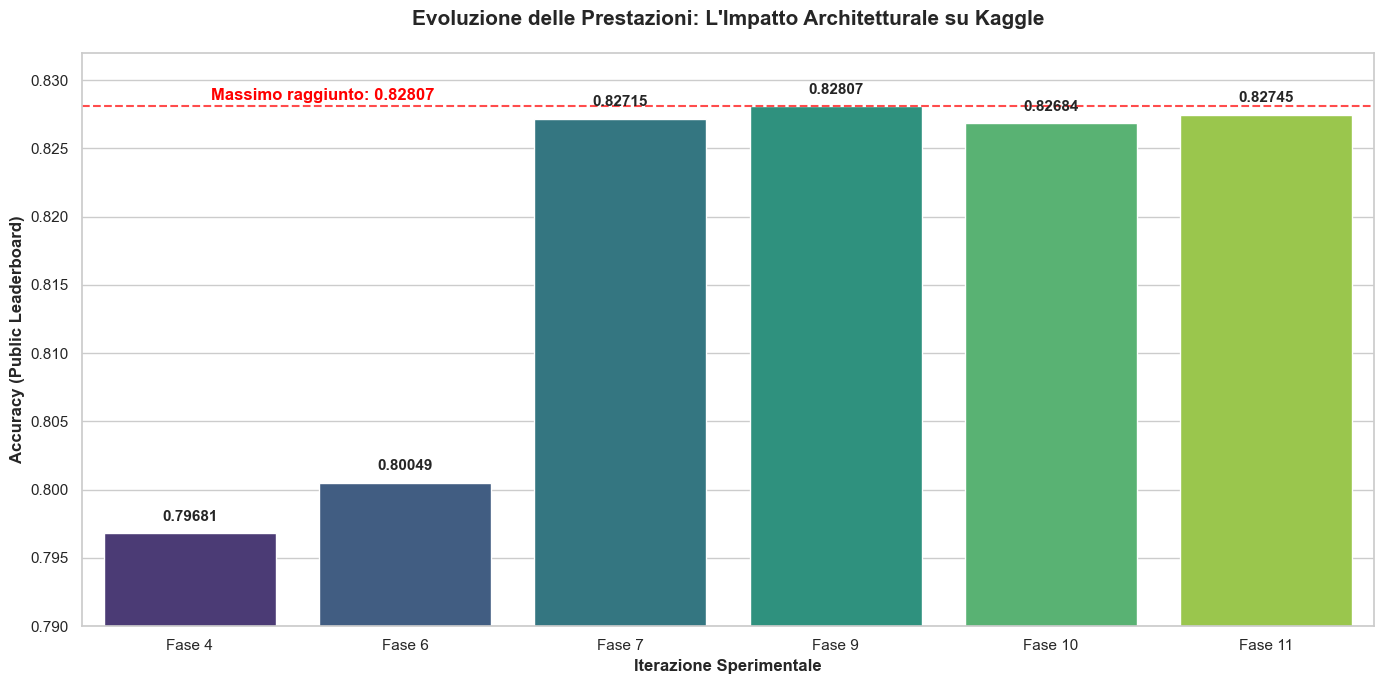

In [28]:
# --- FASE 12: PROJECT POST-MORTEM & EXECUTIVE SUMMARY (CON GRAFICI) ---
# OBIETTIVO: Generare la Leaderboard interna e visualizzare l'impatto architetturale.
# METODO: Comparazione metrica e grafica dei punteggi Kaggle definitivi.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("[INFO] AVVIO FASE 12: KAGGLE LEADERBOARD & VISUAL DIAGNOSTICS")
print("="*90)

# 1. COMPILAZIONE DELLA LEADERBOARD DEGLI ESPERIMENTI
experiments = [
    {
        "Fase_Num": 4,
        "Fase": "Fase 4",
        "Architettura": "SVM Baseline (TF-IDF)",
        "Kaggle_Score": 0.79681,
        "Tipo": "ML Classico"
    },
    {
        "Fase_Num": 6,
        "Fase": "Fase 6",
        "Architettura": "Trinity Ensemble (SVM+SGD+MNB)",
        "Kaggle_Score": 0.80049,
        "Tipo": "ML Ensemble"
    },
    {
        "Fase_Num": 7,
        "Fase": "Fase 7",
        "Architettura": "RoBERTa Base (Deep Learning)",
        "Kaggle_Score": 0.82715,
        "Tipo": "Transformer"
    },
    {
        "Fase_Num": 9,
        "Fase": "Fase 9",
        "Architettura": "RoBERTa + XGBoost (Structural)",
        "Kaggle_Score": 0.82807,
        "Tipo": "Hybrid DL/ML"
    },
    {
        "Fase_Num": 10,
        "Fase": "Fase 10",
        "Architettura": "Surgical Pseudo-Labeling",
        "Kaggle_Score": 0.82684,
        "Tipo": "Self-Training"
    },
    {
        "Fase_Num": 11,
        "Fase": "Fase 11",
        "Architettura": "Orthogonal Veto (DL + Trinity)",
        "Kaggle_Score": 0.82745,
        "Tipo": "Ensemble"
    }
]

# Creazione DataFrame
df_all = pd.DataFrame(experiments)

# Ordinamento per SCORE (Leaderboard Terminale)
df_leaderboard = df_all.sort_values(by="Kaggle_Score", ascending=False).reset_index(drop=True)

# Ordinamento CRONOLOGICO (Per il Grafico Evolutivo)
df_plot = df_all.sort_values(by="Fase_Num").reset_index(drop=True)

# 2. STAMPA DELLA LEADERBOARD FORMATTATA A TERMINALE
print(f"{'RANK':<5} | {'FASE':<10} | {'SCORE':<7} | {'ARCHITETTURA':<35}")
print("-" * 90)

for idx, row in df_leaderboard.iterrows():
    rank = f"#{idx + 1}"
    mark = "🏆 WINNER" if idx == 0 else ""
    print(f"{rank:<5} | {row['Fase']:<10} | {row['Kaggle_Score']:.5f} | {row['Architettura']:<35} {mark}")

print("="*90)

# ==============================================================================
# 3. GENERAZIONE DIAGNOSTICA GRAFICA (EXECUTIVE SUMMARY PLOT)
# ==============================================================================
print(" [PLOT] Generazione grafico riepilogativo in corso...")

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Creazione del Barplot in ordine cronologico
ax = sns.barplot(
    x="Fase",
    y="Kaggle_Score",
    data=df_plot,
    hue="Fase",
    palette="viridis",
    legend=False
)

# Taglio dell'asse Y per enfatizzare il salto tra ML Classico e Deep Learning
plt.ylim(0.79000, 0.83200)

plt.title("Evoluzione delle Prestazioni: L'Impatto Architetturale su Kaggle", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Accuracy (Public Leaderboard)", fontsize=12, fontweight='bold')
plt.xlabel("Iterazione Sperimentale", fontsize=12, fontweight='bold')

# Annotazione dei valori esatti in cima ad ogni barra
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.5f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 12),
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

# Aggiunta della linea di riferimento per il vincitore assoluto (Fase 9)
best_score = df_leaderboard['Kaggle_Score'].max()
plt.axhline(y=best_score, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(x=0.1, y=best_score + 0.0005, s=f'Massimo raggiunto: {best_score:.5f}', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

